### $$\underline{\text{DHF : Lab 2}}$$ 

##### $$\text{Arnaud Capitan, Vasco Nappa, Achraf Ouboujemaa}$$ 
___



### Librairies

In [1]:
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt

___

### Data Loading

In [2]:
stock_ids = ["0","1","2"]
day_ids = ["0","1","2","3","4"]
extensions = ["updates","trades"]

trades = np.zeros((len(stock_ids), len(day_ids)), dtype=pd.DataFrame)
updates = np.zeros((len(stock_ids), len(day_ids)), dtype=pd.DataFrame)

def get_data_path(stock_id, day, extension):
    return f"Data/stock{stock_id}_day{day}_{extension}.csv.gz"

for stock_id in stock_ids :
    for day_id in day_ids :
        data_path_updates = get_data_path(stock_id, day_id, "updates")
        data_path_trades = get_data_path(stock_id, day_id, "trades")
        df_updates = pd.read_csv(data_path_updates)
        df_trades = pd.read_csv(data_path_trades)
        df_updates["ts"] = pd.to_datetime(df_updates["ts"])
        df_trades["ts"] = pd.to_datetime(df_trades["ts"])
        updates[stock_ids.index(stock_id), day_ids.index(day_id)] = df_updates
        trades[stock_ids.index(stock_id), day_ids.index(day_id)] = df_trades

### Test of data loading :

In [3]:
print(updates[0,0].head())

                          ts type  bp       bq  ap       aq
0 2026-01-26 09:00:00.340497    U NaN  19671.0 NaN  24789.0
1 2026-01-26 09:00:00.503532    U NaN  19671.0 NaN  24789.0
2 2026-01-26 09:00:00.503539    U NaN  19671.0 NaN  24789.0
3 2026-01-26 09:00:00.503565    U NaN  19671.0 NaN  24789.0
4 2026-01-26 09:00:00.503735    U NaN  19671.0 NaN  24789.0


In [4]:
print(trades[0,0].head())

   price  qty                         ts
0  55.00    2 2026-01-26 09:00:27.018202
1  55.00   10 2026-01-26 09:00:27.018202
2  55.00   10 2026-01-26 09:00:27.018202
3  54.97  446 2026-01-26 09:00:27.041728
4  54.97   24 2026-01-26 09:00:27.042153


___

### Lab 2 : Questions

___

### 1. Non-homogeneous Poisson process and trade times

We made sure with Lab 1 that the trades dataset was correctly ordered in time, had no negative value for both price and quantity, and that each event time was contained between 9:00 AM and 5:31 PM (since closing time is at 5:30 + random time).

We do not need further data preprocessing for trades data.

___

#### 1.1 Thinning algorithm

We first use the algorithm detailed in Course 3 slide 41 to simulate a non-homogeneous Poisson process on $[0,T]$ by thinning, if we have $\lambda : [0,T] \rightarrow \mathbb{R}_{+}$ our deterministic intensity function bounded by some constant $\lambda ^* \in \mathbb{R} _+ ^*$ on $[0,T]$.

To do so, we can procede either by **global thinning** :

- 1] We generate $(T_i^*) _{1 \leq i \leq n}$ a realization of a time-homogeneous Poisson process with parameter $\lambda ^*$
- 2] We generate $(u_i)_{1 \leq i \leq n} \sim \mathcal{U}([0,1])$ iid
- 3] We then return the set of points ${T_i^* : u_i \leq \dfrac{\lambda(T_i^*)}{\lambda^*}}$

Or we can procede with **thinning per interarrival time** :

- 1] We initialize $t = 0$ and $i = 1$
- 2] We generate $s \sim \mathcal{E}(\lambda ^*)$, which can be done using a random uniform variable given the parameter $\lambda^*$
- 3] If $t+s \leq T$, then :
    - 3.1] We generate $u \sim \mathcal{U}([0,1])$
    - 3.2] If $u \leq \dfrac{\lambda (t-s)}{\lambda ^*}$, we set $t_i = t + s$ and $i = i + 1$
    - 3.3] We increment $t = t + s$
    - 3.4] We repeat the previous steps from 2], until the condition of 3] is not met
- 4] We return the times $(t_i)_{1 \leq i \leq n}$ simulated, which represent our Non Homogeneous Poisson Process



___

We simulate **Time-homogeneous Poisson simulation using inter-arrival exponential times** :

- 1] Initialize $t=0$, $i=1$
- 2] Simulate $s \sim \mathcal{E}(\lambda)$ with $s = - \dfrac{1}{\lambda} \log (u)$ and $u \sim \mathcal{U}([0,1])$
- 3] If $t+s \leq T$ :
    - 3.1] We set $t_i = t+s$ and we update $t = t+s$, $i=i+1$
    - 3.2] We start again from 2], until condition 3] is not met
- 4] When $t+s > T$, we return the $(t_i)_{i \geq 1}$ generated

In [5]:
def exponential_variable(lambda_intensity):
    u = np.random.uniform(0,1)
    s = -np.log(1-u)/lambda_intensity
    return s

Since np.random.uniform(0,1) generates a random number in [0,1[ we will be using 1-u which also follows the same law as u, but removes the possible error of having $\log (0)$

In [6]:
def homogeneous_poisson_process(lambda_intensity,T):
    t = 0
    i = 1
    L = []
    s = exponential_variable(lambda_intensity)
    while t+s < T:
        t = t + s
        L.append(t)
        s = exponential_variable(lambda_intensity)
    return L

To verify our simulation algorithm, we can do Monte-Carlo simulations and check that the other Time-Homogeneous Poisson properties are met.

- The average number of time generated should be $n = \mathbb{E}[\mathcal{P}(\lambda T)] = \lambda T$
- The order statistics should follow the uniform distributions on $[0,1]$

Mean number of events: 50.1222 	 Theoretical mean: 50


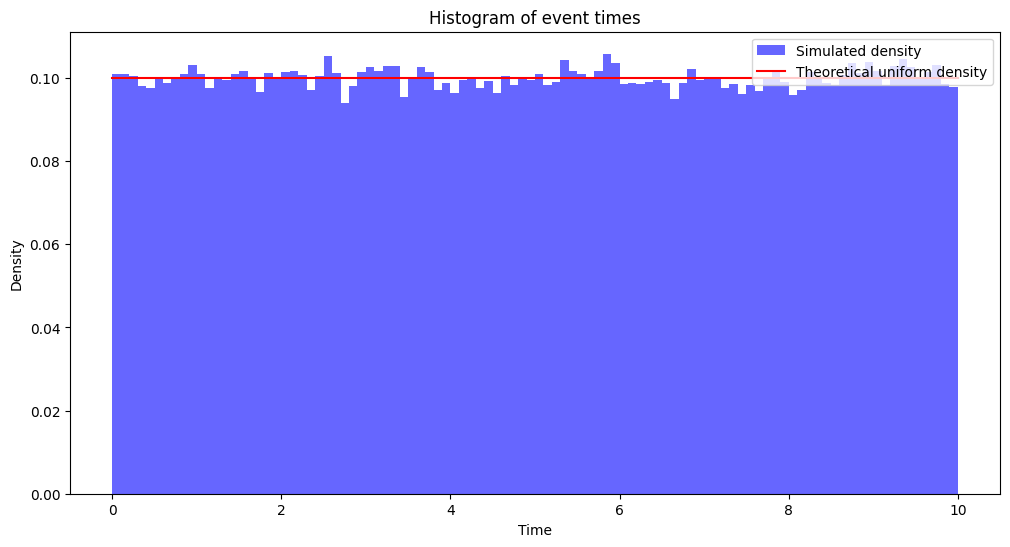

In [7]:
lambda_intensity = 5
T = 10
N_monte_carlo = 5000
L_len = []
L_times = []
for _ in range(N_monte_carlo):
    T_simulated = homogeneous_poisson_process(lambda_intensity,T)
    L_len.append(len(T_simulated))
    L_times += T_simulated

print(f"Mean number of events: {np.mean(L_len):.4f} \t Theoretical mean: {lambda_intensity*T}")

L_times = sorted(L_times)
plt.figure(figsize=(12,6))
plt.hist(L_times, bins=100, density=True, alpha=0.6, color='b', label = "Simulated density")
plt.plot([0, T], [1/T,1/T], color='r', label = "Theoretical uniform density")
plt.legend()
plt.title("Histogram of event times")
plt.xlabel("Time")
plt.ylabel("Density")
plt.show()


Our simulation algorithm for time-homogeneous Poisson Process seems to be working, as both the mean number of time generated and the order statistics correctly follow the theoretical values.

___

We use it for the non-homogeneous poisson process simulation :

In [8]:
def nhpp_simulation_global_thinning(mu_intensity,lambda_star,T):
    T_star = homogeneous_poisson_process(lambda_star,T)
    n = len(T_star)
    L = [np.random.uniform(0,1) for _ in range(n)]
    T = []
    for i in range(n):
        if L[i] <= mu_intensity(T_star[i])/lambda_star:
            T.append(T_star[i])
    return(T)
    

To test the Non-homogeneous Poisson process algorithm, we will use the **Time Change result**, which can be used as a **goodness-of-fit test** when applied to empirical data :

___

For $\tilde{N}$ a non-homogeneous Poisson process with intensity function $t \rightarrow \lambda (t)$, and $(S_i)_{i \geq 1}$ the random times of counted events.

Then the following random variables verify $(\Lambda(S_i)-\Lambda(S_{i-1}))_{i \geq 2} \sim \mathcal{E}(1)$ i.i.d

Recall that the intensity measure $\Lambda(t) = \int _0 ^t \lambda (s) ds$, with $t \rightarrow \lambda (t)$ our Poisson process intensity locally integrable.

___

In [9]:
def approximate_intensity_measure(lambda_intensity, t):
    result = scipy.integrate.quad(lambda x: lambda_intensity(x), 0, t)[0]
    return result

Let's start with an example :

$\lambda (t) = 3+\sin (2\pi t)$

We have $\forall t, \quad |\lambda (t) | \leq \lambda ^* = 4$ 

In [10]:
def lambda_function_example(x):
    y = 3+np.sin(2*np.pi*x)
    return y

def lambda_measure_example(t):
    result = approximate_intensity_measure(lambda_function_example, t)
    return result

We test with the above time change result if the non-homogeneous poisson process simulation works :

In [11]:
def monte_carlo_nhpp_time_change_test(lambda_intensity, lambda_star, T, N_monte_carlo):
    L = []
    for _ in range(N_monte_carlo):
        T_simulated = nhpp_simulation_global_thinning(lambda_intensity, lambda_star, T)
        n = len(T_simulated)
        for i in range(n-1):
            result = lambda_measure_example(T_simulated[i+1]) - lambda_measure_example(T_simulated[i])
            L.append(result)
    L_times = sorted(L)
    plt.figure(figsize=(12,6))
    plt.hist(L_times, bins=100, density=True, alpha=0.6, color='b', label = "Simulated density of time-changed event times")
    x_exp = np.arange(0, T, 1/1000)
    y_exp = np.exp(-x_exp)
    plt.plot(x_exp, y_exp, color='r', label = "Theoretical exponential 1 density")
    plt.legend()
    plt.title("Histogram of time-changed event times for NHPP")
    plt.xlabel("Time")
    plt.ylabel("Density")
    plt.show()

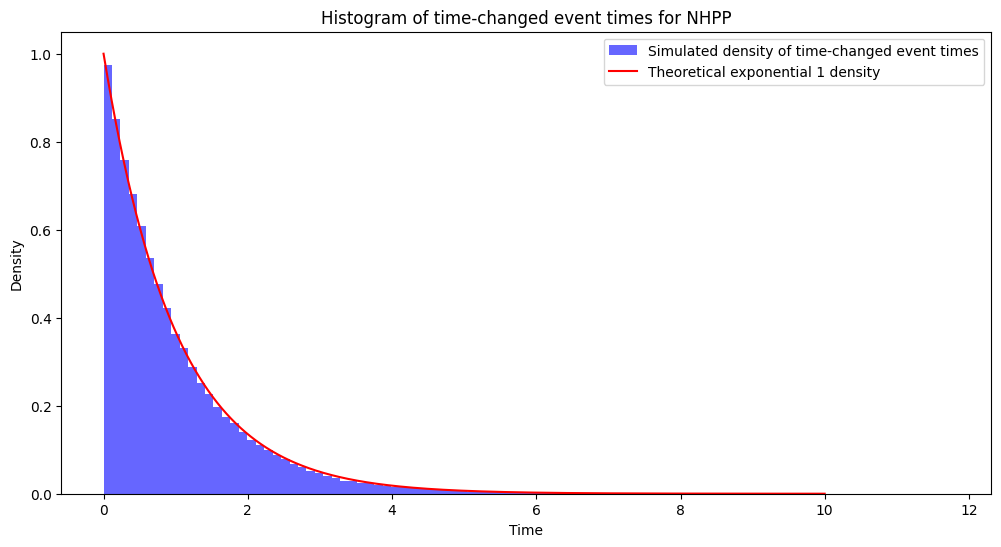

In [12]:
monte_carlo_nhpp_time_change_test(lambda_function_example, 4, T, 5000)

The Monte-Carlo simulation gives the correct theoretical result based on the simulation.

We can then try to approximate the intensity function based on the times generated, which will be helpful for the next question.

We have that :

$\lambda (t) \approx \dfrac{\text{Mean number of events in }[t,t+\delta t]}{\delta t}$

So the Monte-Carlo estimation gives us :

$ \hat{\lambda} = \dfrac{1}{N_{\text{MC}} \delta t} \sum _{i=1} ^{N_{\text{MC}}} N_i([t_i,t_i + \delta t]) $

In [13]:
def monte_carlo_nhpp_density_test(lambda_intensity, lambda_star, T, N_monte_carlo):
    L = []
    for _ in range(N_monte_carlo):
        T_simulated = nhpp_simulation_global_thinning(lambda_intensity, lambda_star, T)
        L += T_simulated
    L_times = sorted(L)
    delta_t = T/1000
    lambda_estimated, edges = np.histogram(L_times, bins=1000, range=(0,T))
    lambda_estimated = lambda_estimated / (N_monte_carlo * delta_t)
    bin_centers = (edges[:-1] + edges[1:])/2
    plt.figure(figsize=(12,6))
    plt.plot(bin_centers, lambda_estimated, color='b', label = f"Estimated lambda intensity function with {N_monte_carlo} simulations")
    x_lambda_intensity = np.arange(0, T, T/1000)
    y_lambda_intensity = lambda_function_example(x_lambda_intensity)
    plt.plot(x_lambda_intensity, y_lambda_intensity, color='r', label = "Theoretical lambda intensity function")
    plt.legend()
    plt.title("Estimated vs Theoretical lambda intensity function for NHPP")
    plt.xlabel("Time")
    plt.ylabel("Density")
    plt.show()

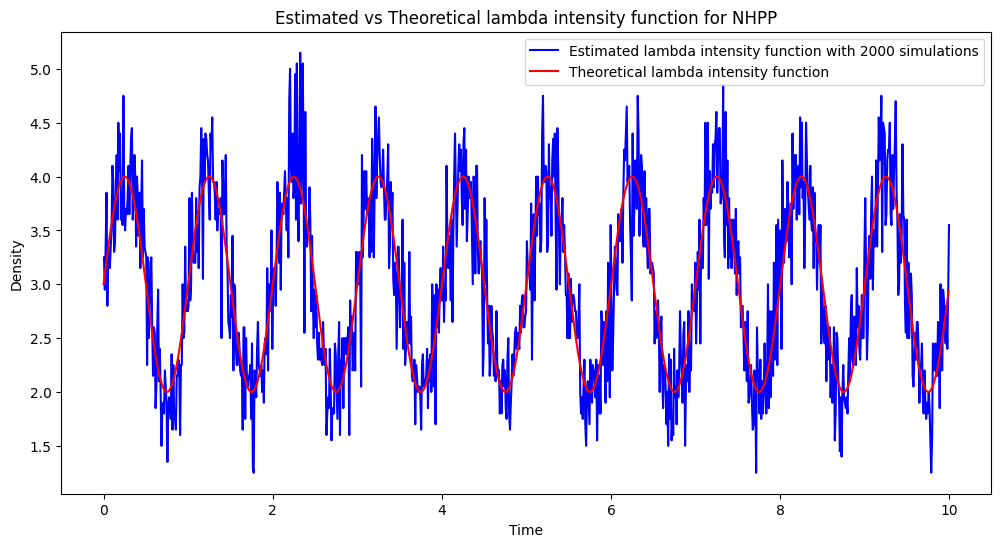

In [14]:
monte_carlo_nhpp_density_test(lambda_function_example, 4, T, 2000)

We have correctly estimated the intensity function, so both our Monte-Carlo simulation and the non-homogeneous poisson process generation algorithm works.

We can observe that by increasing the number of simulations in our Monte-Carlo algorithmn we will obtain a smoother simulated curve : 

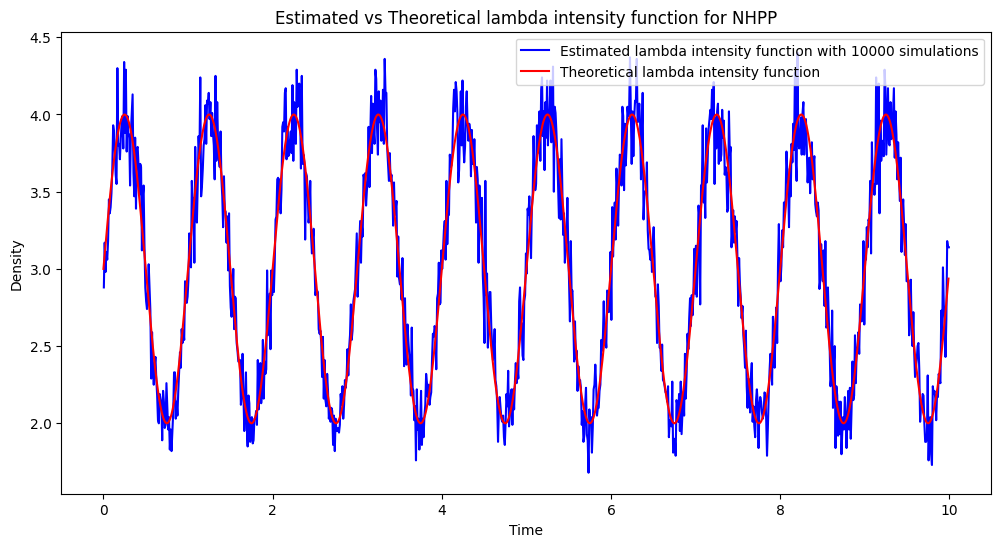

In [15]:
monte_carlo_nhpp_density_test(lambda_function_example, 4, T, 10000)

___

#### 1.2 Dataset intensity function calibration

Since we want for each stock to calibrate a deterministic function that represents the intensity of occurence of trades during a day, we will be using our previous algorithm to compute an estimated intensity function for each stock by merging the trades' event times of the week for each stock.

In [16]:
stock_1_trades_times = []
stock_2_trades_times = []
stock_3_trades_times = []
for day_id in day_ids:
    df_trades = trades[0, day_ids.index(day_id)]
    t0 = df_trades["ts"].iloc[0]
    stock_1_trades_times += list((df_trades["ts"] - t0).dt.total_seconds())
    df_trades = trades[1, day_ids.index(day_id)]
    t0 = df_trades["ts"].iloc[0]
    stock_2_trades_times += list((df_trades["ts"] - t0).dt.total_seconds())
    df_trades = trades[2, day_ids.index(day_id)]
    t0 = df_trades["ts"].iloc[0]
    stock_3_trades_times += list((df_trades["ts"] - t0).dt.total_seconds())

stock_1_trades_times = sorted(stock_1_trades_times)
stock_2_trades_times = sorted(stock_2_trades_times)
stock_3_trades_times = sorted(stock_3_trades_times)

def nhpp_density(points,bin_size=1000,title = "Estimated lambda intensity function",return_values = False,show_plot = True):
    T_end = points[-1]
    T_start = points[0]
    T = T_end - T_start
    delta_t = T/bin_size
    lambda_estimated, edges = np.histogram(points, bins=bin_size, range=(T_start, T_end))
    lambda_estimated = lambda_estimated / (len(day_ids) * delta_t)
    bin_centers = (edges[:-1] + edges[1:])/2
    if show_plot:
        plt.figure(figsize=(12,6))
        plt.plot(bin_centers, lambda_estimated, color='b')
        plt.title(title)
        plt.xlabel("Time")
        plt.ylabel("Density")
        plt.show()
    if return_values:
        return(lambda_estimated, bin_centers)

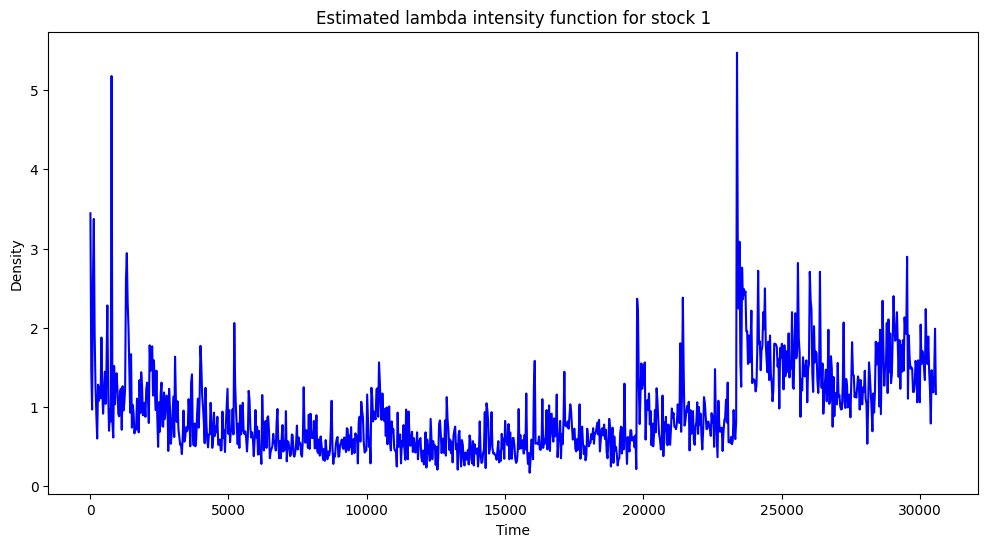

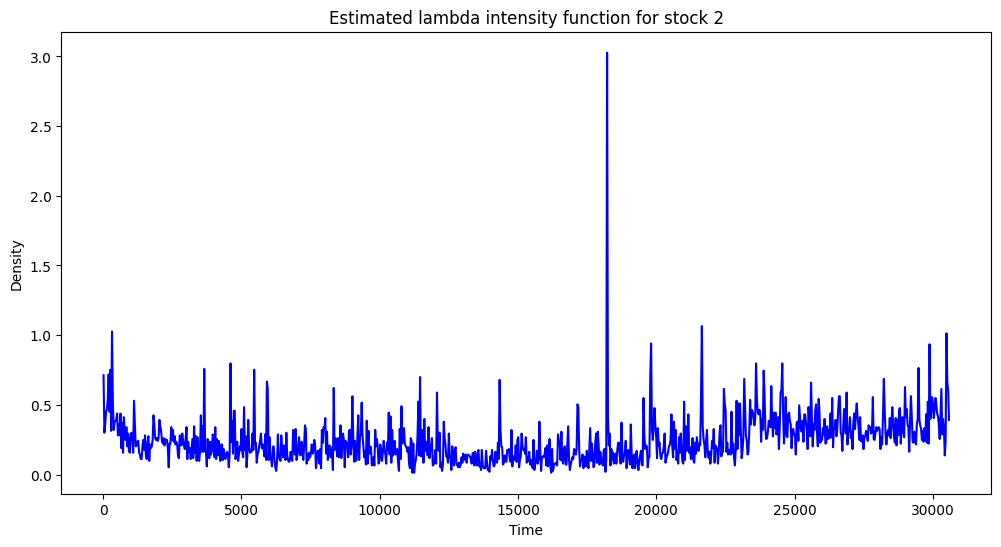

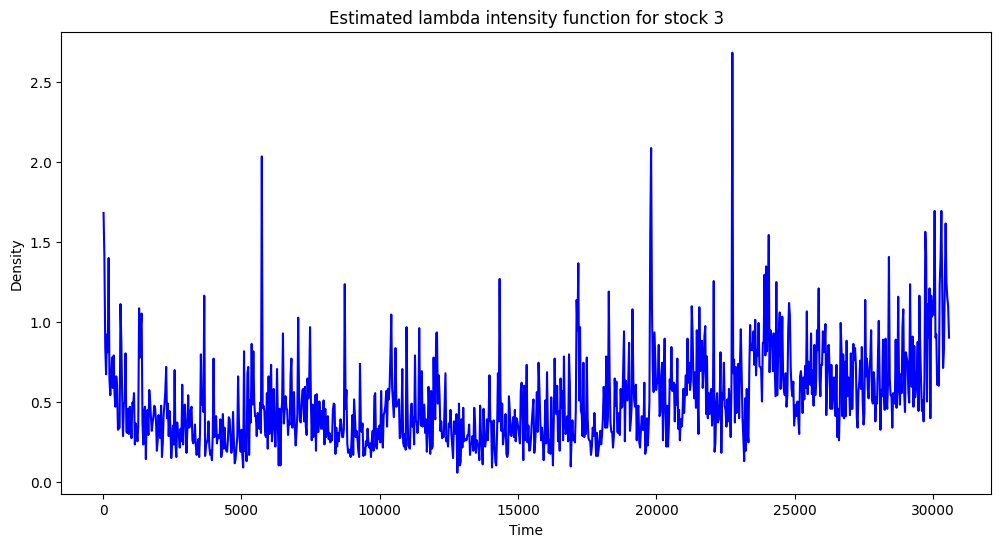

In [17]:
nhpp_density(stock_1_trades_times, bin_size=1000, title = "Estimated lambda intensity function for stock 1")
nhpp_density(stock_2_trades_times, bin_size=1000, title = "Estimated lambda intensity function for stock 2")
nhpp_density(stock_3_trades_times, bin_size=1000, title = "Estimated lambda intensity function for stock 3")

Since we have some real trade data, the result obtained was expected : we don't have a smooth intensity function, but a rather noisy curve.

To try to match a function, we will use a smaller number of bins (classes) to obtain a smoother curve.

We expect to have some kind of **U-shape function** as explained in the slide 48 of course 1, trading activity often has a U-shaped pattern.

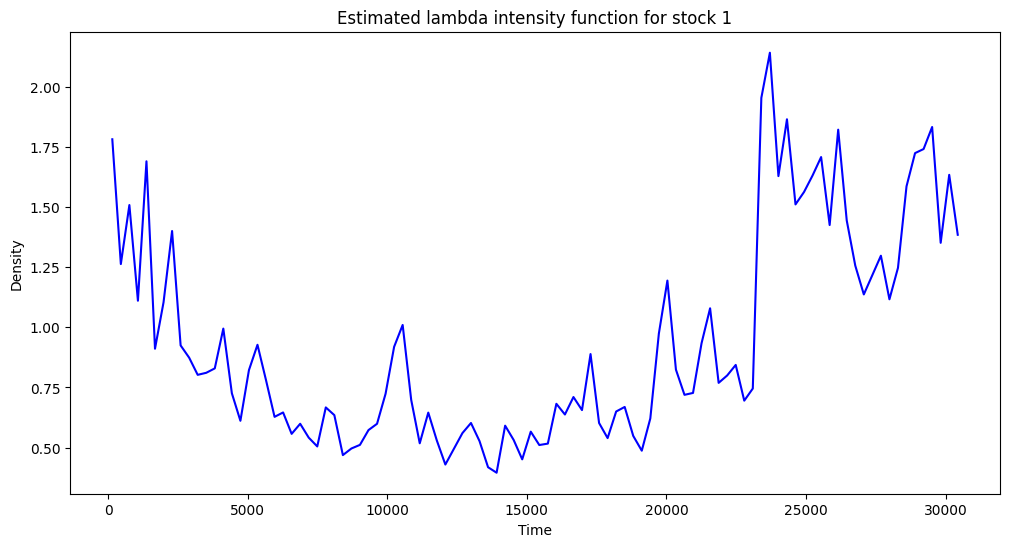

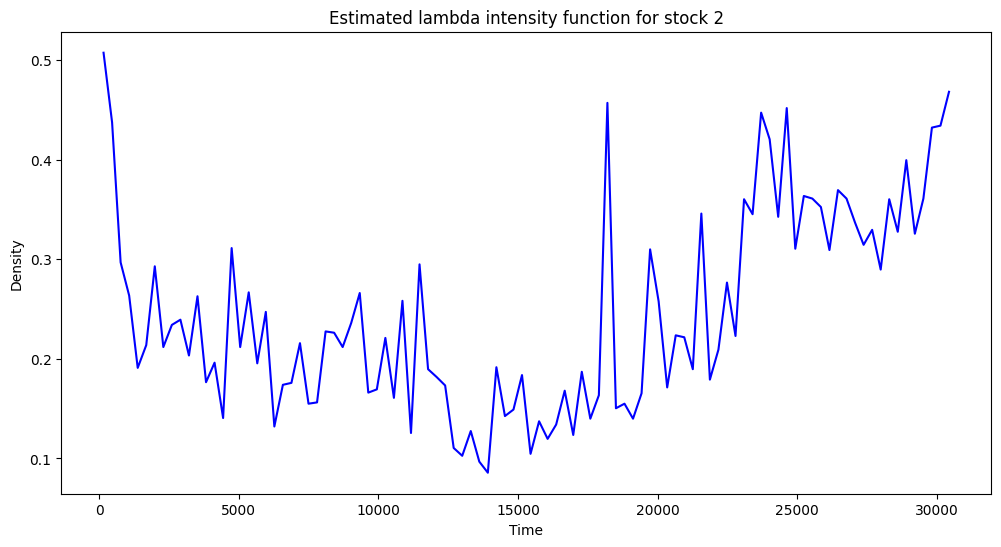

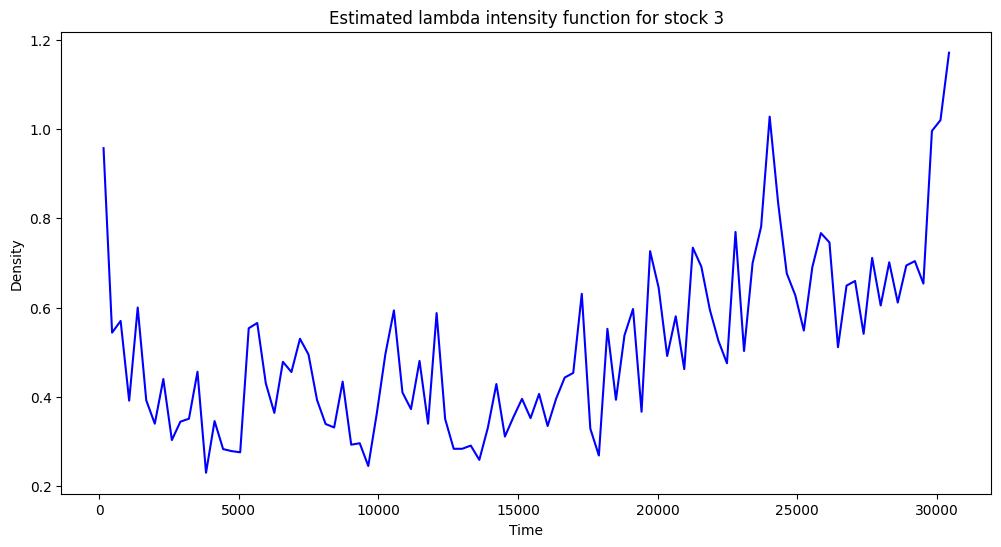

In [18]:
nhpp_density(stock_1_trades_times, bin_size=100, title = "Estimated lambda intensity function for stock 1")
nhpp_density(stock_2_trades_times, bin_size=100, title = "Estimated lambda intensity function for stock 2")
nhpp_density(stock_3_trades_times, bin_size=100, title = "Estimated lambda intensity function for stock 3")

The overall trend seems to be following this U-shape pattern, however because of the noise the statistical test may not yield the best results.

We will then try to match an intraday U-shape intensity function for each stock based on those data.

Power-law function may work to catch the high intensity for both opening and closing, as well as a constant for the middle of the day.

$\lambda (t) = c + A(t + \epsilon)^{-\alpha} + B(T - t + \epsilon)^{-\beta}$

$\epsilon$ is used to prevent errors at $t=0$ and $t=T$, while also making sure the value at those points doesn't go too high.

In [19]:
eps = 10

In [20]:
def lambda_intensity_fit(t,T,A,B,alpha,beta,c,eps):
    t = np.asarray(t)
    return c + A * (t+eps)**(-alpha) + B * (T-t+eps)**(-beta)

def lambda_measure_fit(t,T,A,B,alpha,beta,c,eps):
    result = c*t + A * ((t+eps)**(1-alpha) - eps**(1-alpha))/(1-alpha) + B * ((T+eps)**(1-beta)-(T-t+eps)**(1-beta))/(1-beta)
    return result

We have :

$\Lambda (t) = \int _0 ^t \lambda (s) ds$

The closed form is :

$\Lambda(t) = ct + \dfrac{A}{1-\alpha}[(T+\epsilon)^{1-\alpha} - \epsilon ^{1-\alpha}] + \dfrac{B}{1-\beta} [(T+\epsilon)^{1-\beta} - (T+\epsilon-t)^{1-\beta}]$

___

Now we want to find the optimal parameters for our intensity function.

We wish to maximize the log-likelihood of our non-homogeneous Poisson process intensity function, or equivalentely minimize the negative log-likelihood.

We have from the paper An Introduction to the *Theory of Point Processes: Volume I: Elementary Theory and Methods*, result (2.1.9), an expression of the Likelihood. We derive from it the negative log-likelihood to minimize. 

https://zhanghanjun.weebly.com/uploads/9/5/0/0/9500832/daley_d.j._vere-jones_d._an_intro_to_the_theory_of_point_processes_v1_2nd_ed._springer_2003.pdf

We have :

$L_{(O,T]}(N;t1,...,t_N) = e^{-\Lambda(T)} \prod _{i=1} ^N \lambda (t_i)$

So :

$l(\theta) = \sum _{i=1} ^N \log (\lambda (t_i,\theta)) - \Lambda(T,\theta)$


In [21]:
def neg_log_likelihood(params, points, T, eps):
    A, B, alpha, beta, c = params
    if A <= 0 or B <= 0 or alpha <= 0 or beta <= 0 or c == 0:
        return np.inf
    log_sum = np.sum(np.log(lambda_intensity_fit(points, T, A, B, alpha, beta, c, eps)))
    compensator = lambda_measure_fit(T, T, A, B, alpha, beta, c, eps)
    return -(log_sum - compensator)

___

For stock 1 :

In [22]:
def optimization_function(points,print_result = False):
    params0 = [1.0, 1.0, 0.5, 0.5, 0.1] # A, B, alpha, beta, c

    T = points[-1]

    bounds = [
        (1e-6, None),
        (1e-6, None),
        (1e-6, 0.999),
        (1e-6, 0.999),
        (-10, 10),
    ]

    result = scipy.optimize.minimize(
        neg_log_likelihood,
        params0,
        args=(points, T, eps),
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 10000}
    )

    A_opt, B_opt, alpha_opt, beta_opt, c_opt = result.x
    if print_result:
        print(result)
    return A_opt/5, B_opt/5, alpha_opt, beta_opt, c_opt/5

The optimization process should look like this when succeeding :

In [23]:
optimization_function(stock_1_trades_times, print_result = True)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -86345.7990728619
        x: [ 4.476e+01  4.977e+01  3.269e-01  1.581e-01 -9.072e+00]
      nit: 61
      jac: [-4.805e+00  4.044e+01 -4.557e+02 -9.437e+03  1.386e+02]
     nfev: 474
     njev: 79
 hess_inv: <5x5 LbfgsInvHessProduct with dtype=float64>


(8.951821228840595,
 9.954115393270014,
 0.3269171564207503,
 0.1581432100559175,
 -1.814439651090521)

Since we merged the data points of the 5 days, we need to divide the obtained intensity by 5.

$\lambda _{\text{5 days}}(t) = c + A(t+\epsilon)^{-\alpha} + B(T-t+\epsilon)^{-\beta}$

$\lambda _{\text{day}} (t) = \dfrac{c}{5} + \dfrac{A}{5}(t+\epsilon)^{-\alpha} + \dfrac{B}{5} (T-t+\epsilon)^{-\beta}$

In [24]:
def plot_results_fitted_lambda(points, params, bin_size=1000, title = ""):
    A, B, alpha, beta, c = params
    T = stock_1_trades_times[-1]
    x_theoretical = np.linspace(0, T, 1000)
    y_theoretical = lambda_intensity_fit(x_theoretical, T, A, B, alpha, beta, c, eps)
    plt.figure(figsize=(12,6))
    plt.plot(x_theoretical, y_theoretical, color='r', label = "Fitted lambda intensity function")
    delta_t = T/bin_size
    lambda_estimated, edges = np.histogram(points, bins=bin_size, range=(0, T))
    lambda_estimated = lambda_estimated / (len(day_ids) * delta_t)
    bin_centers = (edges[:-1] + edges[1:])/2
    plt.plot(bin_centers, lambda_estimated, color='b')
    plt.xlabel("Time")
    plt.ylabel("Intensity")
    plt.title(title)
    plt.show()

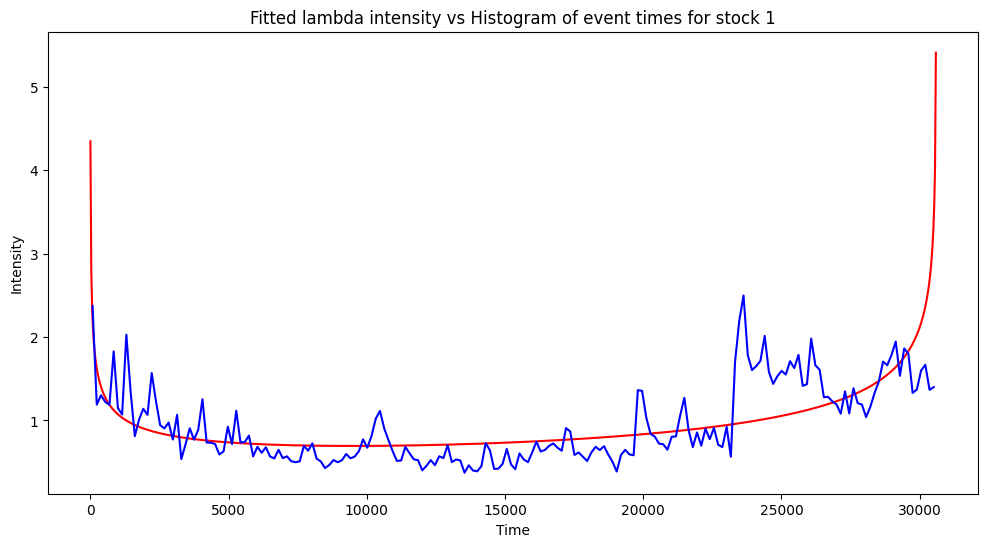

In [25]:
stock_1_params = optimization_function(stock_1_trades_times)
plot_results_fitted_lambda(stock_1_trades_times, stock_1_params, bin_size=200, title = "Fitted lambda intensity vs Histogram of event times for stock 1")

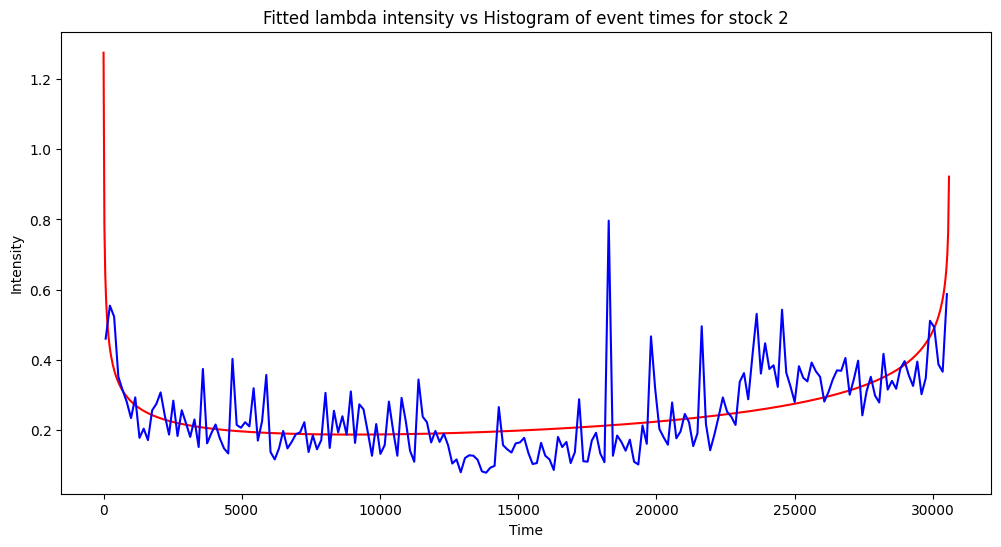

In [26]:
stock_2_params = optimization_function(stock_2_trades_times)
plot_results_fitted_lambda(stock_2_trades_times, stock_2_params, bin_size=200, title = "Fitted lambda intensity vs Histogram of event times for stock 2")

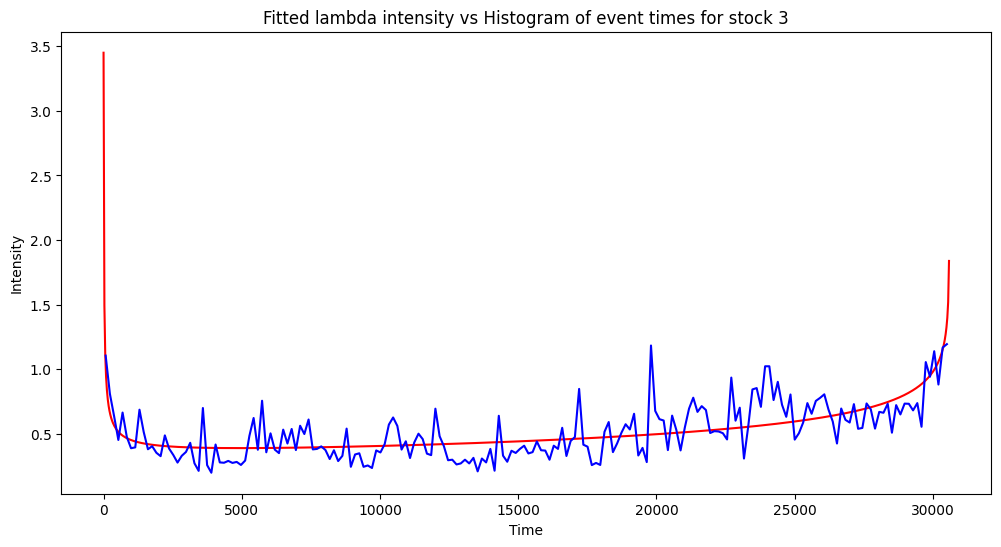

In [27]:
stock_3_params = optimization_function(stock_3_trades_times)
plot_results_fitted_lambda(stock_3_trades_times, stock_3_params, bin_size=200, title = "Fitted lambda intensity vs Histogram of event times for stock 3")

The obtained fitted intensity function for each stock match more or less the trade event times given in the data. It is particularly satisfaying for stock 2 and 3, where it fits correctly the model, but stock 1 presents a high counts of events in the range 23000 to 26000 seconds, so approximately between 3pm and 4pm.

To see if our optimal intensity functions correctly match the data provided, we will make so statistical tests by computing :
- The total number of events for each stock $N_{\text{events}}$, to compare with $N_{\text{5 days}} \times \Lambda(T)$ as both should match
- A QQ-plot of time-changed event times given $\Lambda(t)$ function, to compare with $\mathcal{E}(1)$
- The time-change density (same as the Monte-Carlo we did earlier) of our data with the function we estimated, to compare with $\mathcal{E}(1)$

___

**Mean number of events predicted** vs **Total number of events**

In [28]:
print(f"Stock 1 number of events : {len(stock_1_trades_times)}")
A,B,alpha,beta,c = stock_1_params
T = stock_1_trades_times[-1]
mean_number = len(day_ids)*lambda_measure_fit(T,T,A,B,alpha,beta,c,eps)
print(f"Stock 1 mean number of events : {mean_number}")
print(f"Relative error : {(abs(mean_number-len(stock_1_trades_times))/mean_number):.6f}")

Stock 1 number of events : 143963
Stock 1 mean number of events : 144503.1270785968
Relative error : 0.003738


In [29]:
print(f"Stock 2 number of events : {len(stock_2_trades_times)}")
A,B,alpha,beta,c = stock_2_params
T = stock_2_trades_times[-1]
mean_number = len(day_ids)*lambda_measure_fit(T,T,A,B,alpha,beta,c,eps)
print(f"Stock 2 mean number of events : {mean_number}")
print(f"Relative error : {(abs(mean_number-len(stock_2_trades_times))/mean_number):.6f}")

Stock 2 number of events : 37522
Stock 2 mean number of events : 37524.02460764995
Relative error : 0.000054


In [30]:
print(f"Stock 3 number of events : {len(stock_3_trades_times)}")
A,B,alpha,beta,c = stock_3_params
T = stock_3_trades_times[-1]
mean_number = len(day_ids)*lambda_measure_fit(T,T,A,B,alpha,beta,c,eps)
print(f"Stock 3 mean number of events : {mean_number}")
print(f"Relative error : {(abs(mean_number-len(stock_3_trades_times))/mean_number):.6f}")

Stock 3 number of events : 78209
Stock 3 mean number of events : 78170.27342298396
Relative error : 0.000495


The mean number of events match **very closely** the number of events from our dataset, so this is a pretty good first indicator that our intensity functions match our dataset.

___

**QQ-plot**

In [31]:
def qq_plot(points,params,title = ""):
    A,B,alpha,beta,c = params
    T = points[-1]
    u = np.array([lambda_measure_fit(ti,T,A,B,alpha,beta,c,eps) for ti in sorted(points)])
    n = len(u)
    Lambda_T = lambda_measure_fit(T,T,A,B,alpha,beta,c,eps)
    theoretical_quantiles = Lambda_T*(np.arange(1,n+1)-0.5)/n
    plt.figure(figsize=(12, 6))
    plt.plot(theoretical_quantiles, np.sort(u), 'o', markersize=4, label='Data')
    plt.plot([0, Lambda_T], [0, Lambda_T], 'r--', label='y = x')
    plt.xlabel('Theoretical quantiles')
    plt.ylabel('Empirical quantiles of Λ')
    plt.title(title)
    plt.legend()
    plt.show()

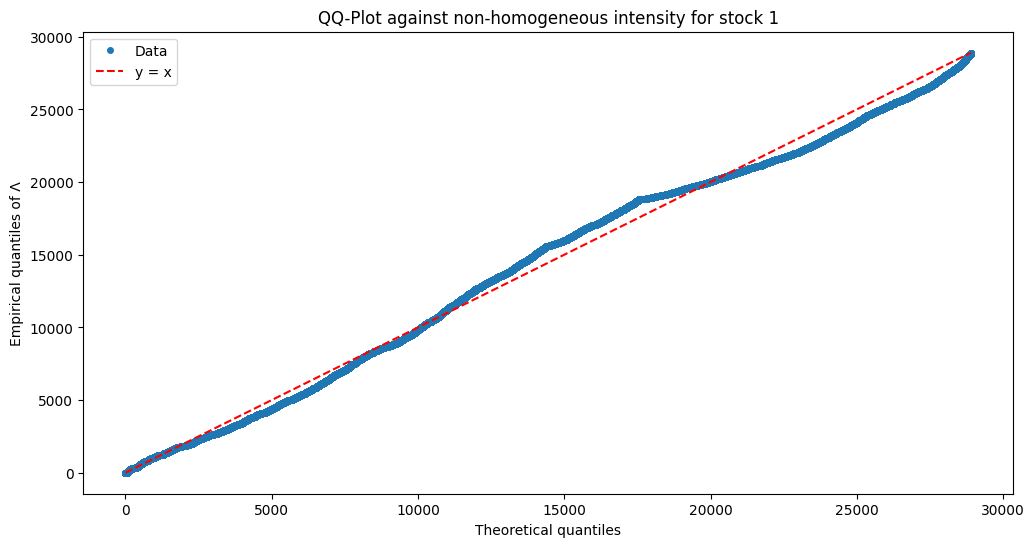

In [32]:
qq_plot(stock_1_trades_times,stock_1_params, title = "QQ-Plot against non-homogeneous intensity for stock 1")

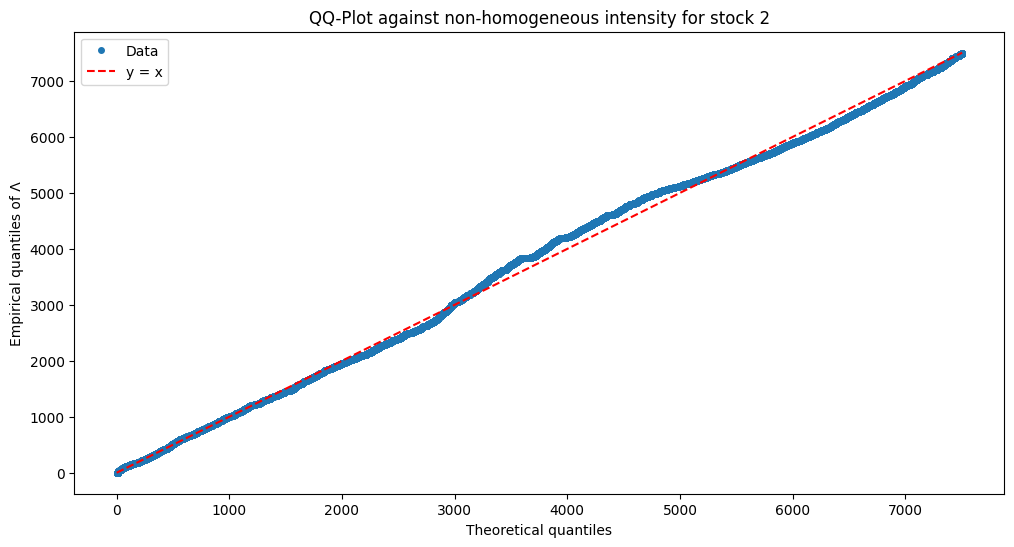

In [33]:
qq_plot(stock_2_trades_times,stock_2_params, title = "QQ-Plot against non-homogeneous intensity for stock 2")

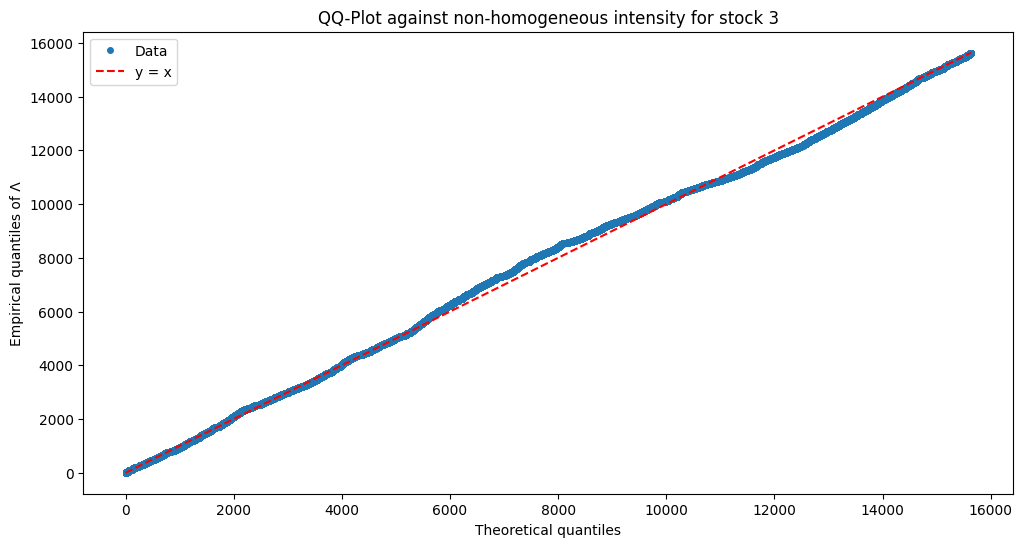

In [34]:
qq_plot(stock_3_trades_times,stock_3_params, title = "QQ-Plot against non-homogeneous intensity for stock 3")

This result is rather satisfaying, as we have for each stock the QQ-plot following the linear trend as expected. Stock 1 is a bit wavy around the y=x curve, but overall the result is correct when we look at QQ-plot in the litterature : **we have a good alignment for each stock**.

___

**Density test with $\mathcal{E}(1)$**

In [35]:
def nhpp_time_change_test(params,points,title=""):
    L = []
    A,B,alpha,beta,c = params
    T = points[-1]
    for i in range(len(points)-1):
        result = lambda_measure_fit(points[i+1],T,A,B,alpha,beta,c,eps) - lambda_measure_fit(points[i],T,A,B,alpha,beta,c,eps)
        L.append(result)
    L_times = sorted(L)
    plt.figure(figsize=(12,6))
    plt.hist(L_times, bins=1000, density=True, alpha=0.6, color='b', label = "Simulated density of time-changed event times")
    x_exp = np.arange(0, T, 1/100)
    y_exp = np.exp(-x_exp)
    plt.plot(x_exp, y_exp, color='r', label = "Theoretical exponential 1 density")
    plt.legend()
    plt.xlim(0,3)
    plt.ylim(0,50)
    plt.yscale("symlog")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Density")
    plt.show()

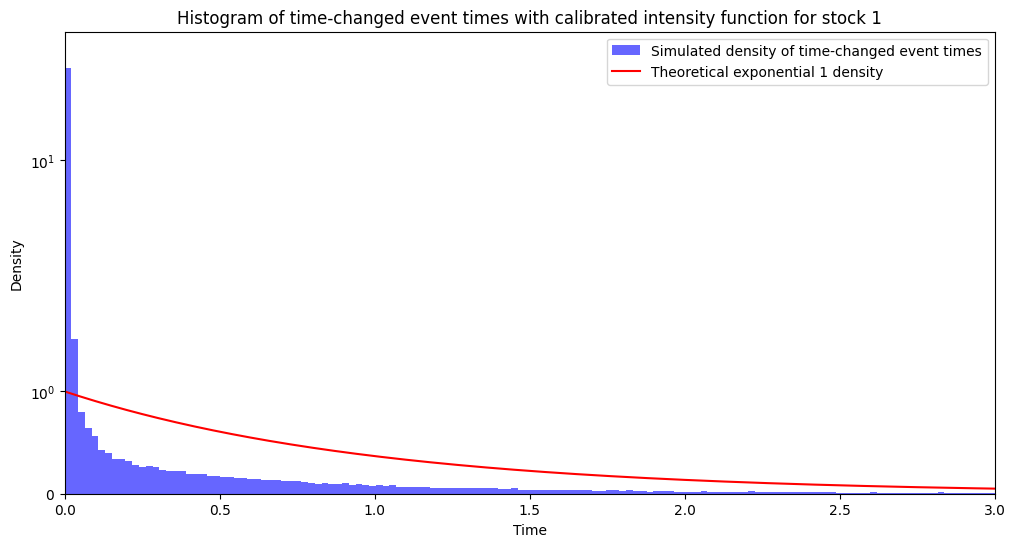

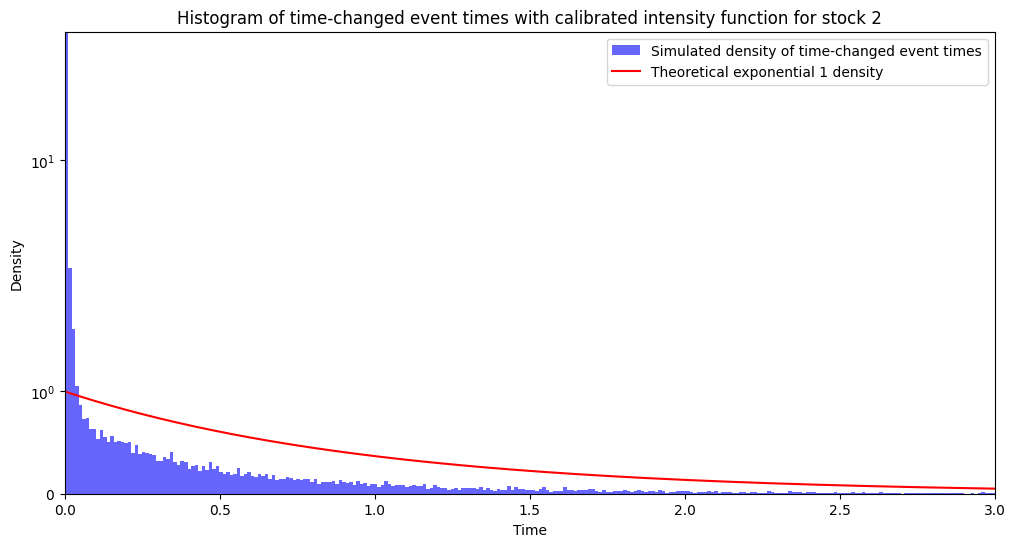

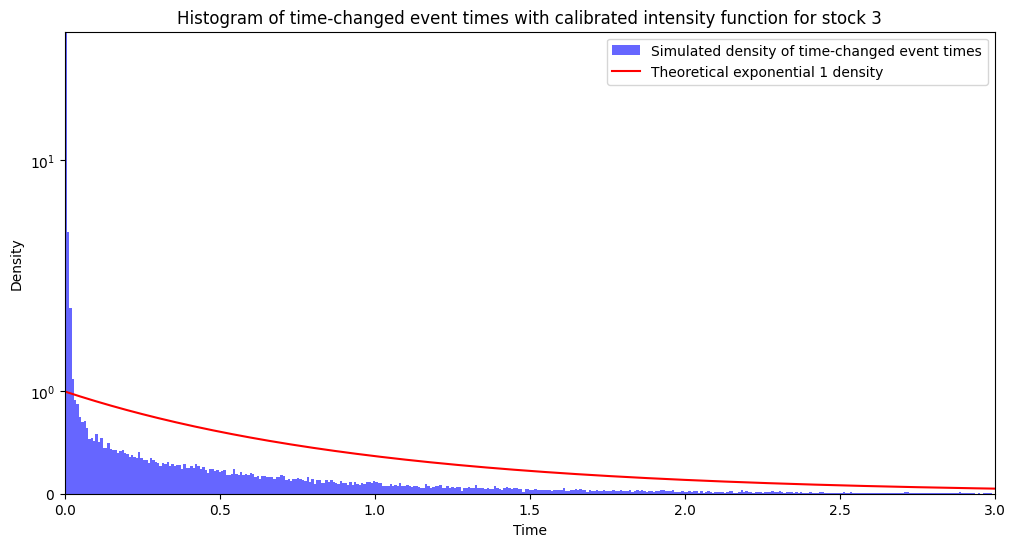

In [36]:
nhpp_time_change_test(stock_1_params,stock_1_trades_times,"Histogram of time-changed event times with calibrated intensity function for stock 1")
nhpp_time_change_test(stock_2_params,stock_2_trades_times,"Histogram of time-changed event times with calibrated intensity function for stock 2")
nhpp_time_change_test(stock_3_params,stock_3_trades_times,"Histogram of time-changed event times with calibrated intensity function for stock 3")

Those tests yield poor results compared to the other tests, and compared to the simulation of our non-homogeneous Poisson process algorithm we did earlier on, where we obtained a similar graph but the empirical histogram was much close to the theoretical $\mathcal{E}(1)$ density.

It looks closer to a power-law with a singularity at 0 than to an exponential distribution ; we can still observe a fast decay in the density, and that given we remove the singularity at 0, we may find the correct result.

In [37]:
def nhpp_time_change_test_modified_singularity(params,points,treshold,title=""):
    L = []
    A,B,alpha,beta,c = params
    T = points[-1]
    for i in range(len(points)-1):
        result = lambda_measure_fit(points[i+1],T,A,B,alpha,beta,c,eps) - lambda_measure_fit(points[i],T,A,B,alpha,beta,c,eps)
        L.append(result)
    L_times = sorted(L)
    L_times = [x for x in L_times if x > treshold]
    plt.figure(figsize=(12,6))
    plt.hist(L_times, bins=500, density=True, alpha=0.6, color='b', label = "Simulated density of time-changed event times")
    x_exp = np.arange(0, T, 1/100)
    y_exp = np.exp(-x_exp)
    plt.plot(x_exp, y_exp, color='r', label = "Theoretical exponential 1 density")
    plt.legend()
    plt.xlim(0,5)
    plt.ylim(0,3)
    title = "Histogram of time-changed event times with calibrated intensity function for " + title + ", singularity removed" 
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Density")
    plt.show()

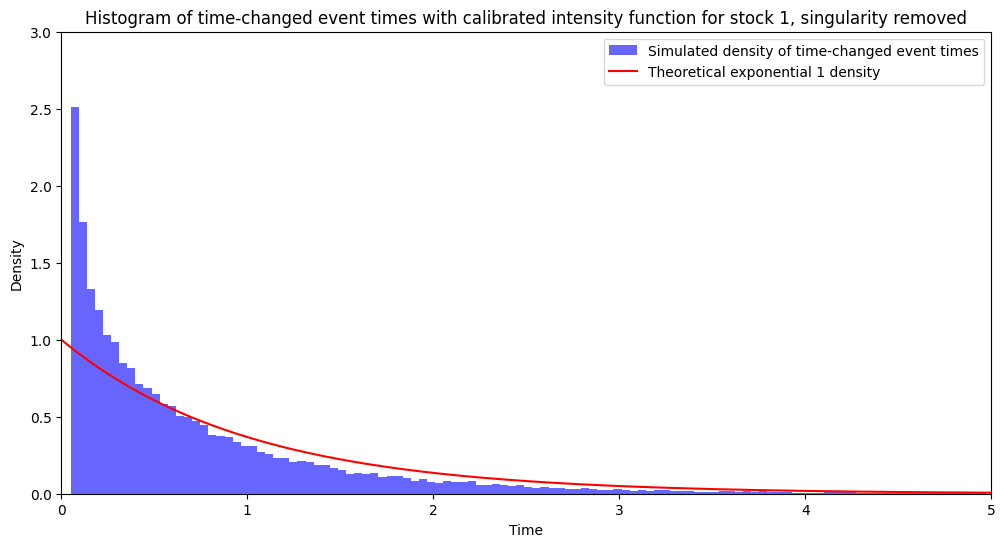

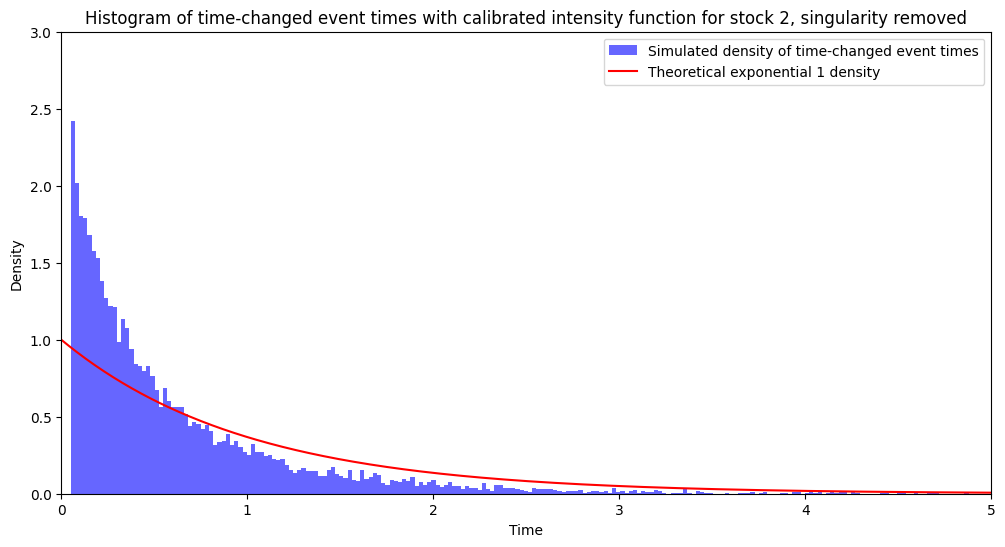

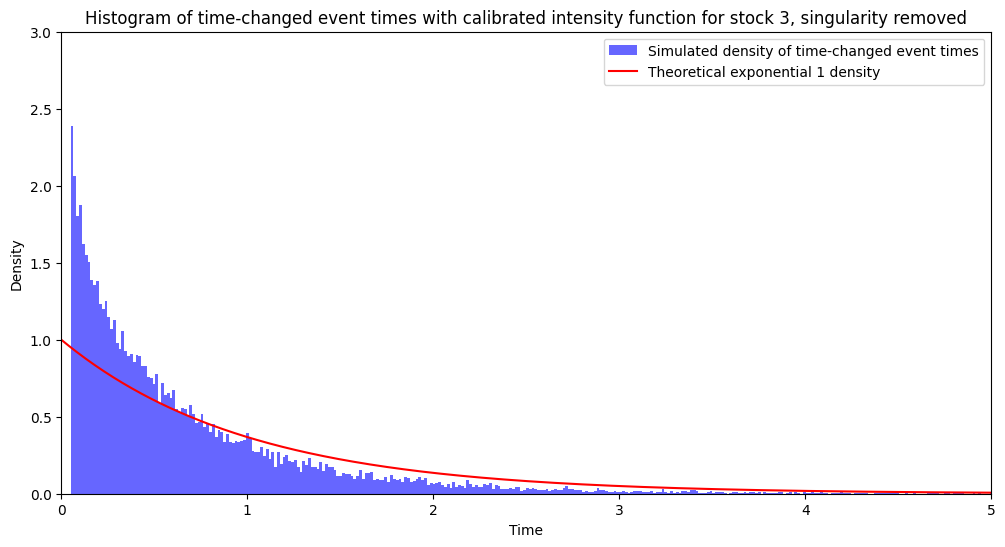

In [38]:
treshold = 0.05
nhpp_time_change_test_modified_singularity(stock_1_params,stock_1_trades_times,treshold,"stock 1")
nhpp_time_change_test_modified_singularity(stock_2_params,stock_2_trades_times,treshold,"stock 2")
nhpp_time_change_test_modified_singularity(stock_3_params,stock_3_trades_times,treshold,"stock 3")

By removing the singularity at 0, we obtain a graph closer to the exponential distribution. However it remains apparent that the time-changed distribution is driven by some power law by looking at the behaviour at 0. The differences between the two distributions being not that big allow the previous statistical tests (QQ-plot and mean) to yield the correct results. 

Looking back at what we did, using another kind of function but with exponential functions instead of power law may fix the issue, we could get an asymmetrical U-shape by using exponential, removing singularities at 0 (and T).

$\lambda _{\text{exp}} (t) = c + A e^{-\alpha t} + B e^{-\beta (T - t)}$

$\Lambda _{\text{exp}} (t) = \int _0 ^t \lambda (s) ds = ct + \dfrac{A}{\alpha}(1 - e^{-\alpha t}) +\dfrac{B}{\beta} (e^{-\beta (T - t)} - e^{-\beta T})$

Similar optimizations algorithms may give a better result with this intensity function ; however I decided to stick with the power law intensity function as I believe it fits closely the kind of U-shape behaviour I was looking for.

___

### 2. Brownian motions with Poisson sampling

In this question we consider two processes $p_i (t) = \sigma _i W_i (t)$, $i = 1,2$ where $W_1$ and $W_2$ are two Brownian motions such that $<W_1,W_2>_t = \rho t$ for some constants $\sigma _1 >0$, $\sigma _2 >0$ and $\rho \in ]-1,1[$

Furthermore, we observe each process $p_i$ on $[0,T]$ at times $T_{i,k}, k \geq 0$ with $T_{i,k}$ being a Poisson process with constant intensity $\mu _i$

In [39]:
sigma1 = 3
sigma2 = 2
rho = 3/7
mu1 = 4
mu2 = 5
T = 100

Since we will need to observe our brownian motions $p_1$ and $p_2$ and random times, we need a lot of data points for both our brownian motions to make sure we can observe their values at the $T_{i,k}$ generated.

In [40]:
def p1_p2(sigma1,sigma2,rho,T,N_times = 100000):
    dt = T/N_times
    times = np.linspace(0,T,N_times+1)
    dW1 = np.random.normal(0, np.sqrt(dt),N_times) #sqrt(t) for the standard deviation, to get t as variance
    dW2 = rho*dW1 + np.sqrt(1-rho**2)*np.random.normal(0,np.sqrt(dt),N_times)
    W1 = np.concatenate([[0],np.cumsum(dW1)])
    W2 = np.concatenate([[0],np.cumsum(dW2)])
    p1 = sigma1*W1
    p2 = sigma2*W2
    return(times,p1,p2)

In [41]:
def observation_times_p1_p2(mu1,mu2,T):
    T1 = homogeneous_poisson_process(mu1,T)
    T2 = homogeneous_poisson_process(mu2,T)
    return(T1,T2)

def observe_p1_p2(p1,p2,T1,T2,times):
    indices1 = np.searchsorted(times,T1)
    indices2 = np.searchsorted(times,T2)
    return (p1[indices1],p2[indices2])

We will now simulate multiple sample paths of the observed processes (based on the random observation times), and then compute for each path the standard covariance estimator of $[p_1,p_2]_T = \rho \sigma _1 \sigma _2 T$ for various sampling periods $\tau$

___ 

https://projecteuclid.org/journals/bernoulli/volume-11/issue-2/On-covariance-estimation-of-non-synchronously-observed-diffusion-processes/10.3150/bj/1116340299.pdf

This article written by Takaki Hayashi and Nakahiro Yoshida called *On covariance estimation of non-synchronously observed diffusion processes* explains in defition 3.1. the (deterministic) covariation of $p_1$ and $p_2$, being :

$ <p_1,p_2> _T = \int _0 ^T \sigma ^1 _t \sigma ^2 _t \rho _t dt$

By replacing the deterministic values above by our constant values, we get the result mentioned in the lab : $[p_1,p_2]_T = \rho \sigma _1 \sigma _2 T$

Note that for correlated continuous Brownian motions (hypothesis that we will consider verified given our case study) we have $[p_1,p_2]_T = <p_1,p_2>_T$

The paper also gives us the standard covariance estimator :

$\widehat{[p_1,p_2]_T} = \sum _{i=1} ^{n_1} \sum _{j=1} ^{n_2} \Delta p_1(T_{1,i}) \cdot \Delta p_2(T_{2,j}) \cdot \mathbf{1} [(T_{1,i-1}, T_{1,i}] \cap (T_{2,j-1}, T_{2,j}] \neq \emptyset]$

Since we want to use sampling periods $\tau$ to compute the standard covariance estimator, we need to resample the Poisson observation times with rate $\tau$ before using the estimator mentioned above.

This can be done with :

$\tilde{T}_{i,k} (\tau) = \sup (T_{i,j} : T_{i,j} \leq k \tau), 1 \leq k \leq \lfloor \dfrac{T}{\tau} \rfloor $

So we get the $\tau$-sampled covariance estimator :

$\widehat{[p_1,p_2]_T}(\tau) = \sum _{k=1} ^{\lfloor T/\tau \rfloor} \sum _{l=1} ^{\lfloor T/\tau \rfloor} \Delta \tilde{p}_1 ^k \cdot \Delta \tilde{p}_2 ^l \cdot \mathbf{1} [((k-1)\tau, k \tau] \cap ((l-1)\tau, l \tau] \neq \emptyset]$

Since we have that $\mathbf{1} [((k-1)\tau, k \tau] \cap ((l-1)\tau, l \tau] \neq \emptyset] = 1 \iff k = l$, we finally get :

$\widehat{[p_1,p_2]_T}(\tau) = \sum _{k=1} ^{\lfloor T/\tau \rfloor} \Delta \tilde{p}_1 ^k \cdot \Delta \tilde{p}_2 ^k $

This also means that for this estimator to yield good results, we must have a change observed for both asset during the different sampling periods, otherwise we will just sum terms that will be equal to 0.



In [42]:
def sample_grid_tau(T_obs,p_obs,tau,T):
    n = int(T/tau)
    p_grid = np.full(n+1,np.nan)
    for k in range(n+1):
        idx = np.searchsorted(T_obs,k*tau,side='right')-1
        if idx >= 0:
            p_grid[k] = p_obs[idx]
    return(p_grid)

To quickly explain the previous code, this line :

idx = np.searchsorted(T_obs,k*tau,side='right')-1

computed the index of the first element stricly greater than $k \tau$ and then removes 1 to get the correct element in this computation :

$\tilde{T}_{i,k} (\tau) = \sup (T_{i,j} : T_{i,j} \leq k \tau), 1 \leq k \leq \lfloor \dfrac{T}{\tau} \rfloor$

The grid gives us the $\tilde{T}_{i,k} (\tau)$

For the code below, the estimator is a dot product of the obtained arrays, for which we filter out with the following mask the nan values for dp1 or dp2:

mask = np.logical_not(np.logical_or(np.isnan(dp1),np.isnan(dp2)))

In [43]:
def standard_covariance_estimator(T1,T2,p1,p2,times,tau):
    p1_obs, p2_obs = observe_p1_p2(p1,p2,T1,T2,times)
    p1_grid = sample_grid_tau(T1,p1_obs,tau,T)
    p2_grid = sample_grid_tau(T2,p2_obs,tau,T)
    dp1 = np.diff(p1_grid)
    dp2 = np.diff(p2_grid)
    mask = np.logical_not(np.logical_or(np.isnan(dp1),np.isnan(dp2)))
    return np.sum(dp1[mask]*dp2[mask])

___

**Now for the simulations and estimations :**

Observation times example (y-axis is meaningless, x axis for time) :

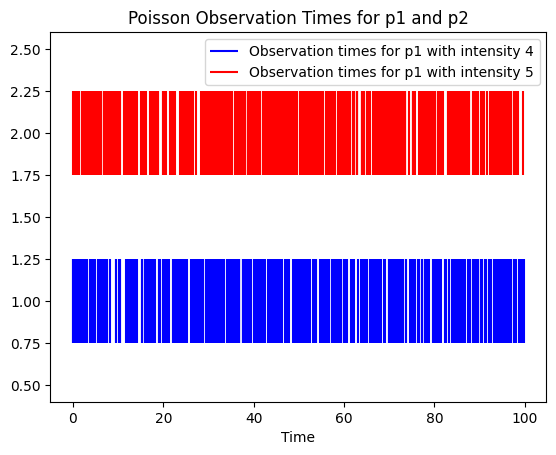

In [44]:
T1,T2 = observation_times_p1_p2(mu1,mu2,T)
plt.eventplot(T1,lineoffsets=1,linelengths=0.5,color='b',label=f'Observation times for p1 with intensity {mu1}')
plt.eventplot(T2,lineoffsets=2,linelengths=0.5,color='r',label=f'Observation times for p1 with intensity {mu2}')
plt.title("Poisson Observation Times for p1 and p2")
plt.xlabel("Time")
plt.legend()
plt.show()

Correlated brownian motions, $p_1$ and $p_2$ :

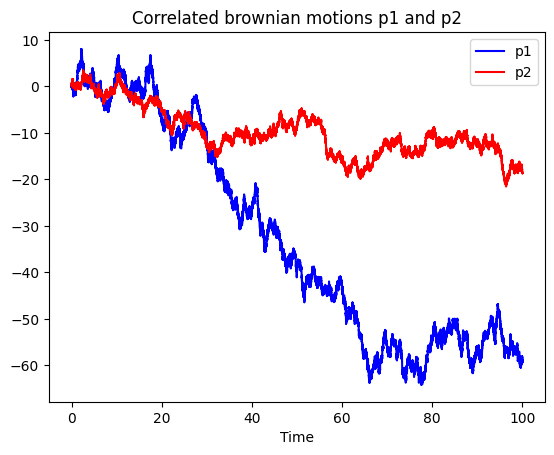

In [45]:
times, p1, p2 = p1_p2(sigma1,sigma2,rho,T)
plt.plot(times,p1,color='b',label="p1")
plt.plot(times,p2,color='r',label="p2")
plt.title("Correlated brownian motions p1 and p2")
plt.xlabel("Time")
plt.legend()
plt.show()


Observed $p_1$ and $p_2$ given random observation times $T_1$ and $T_2$ :

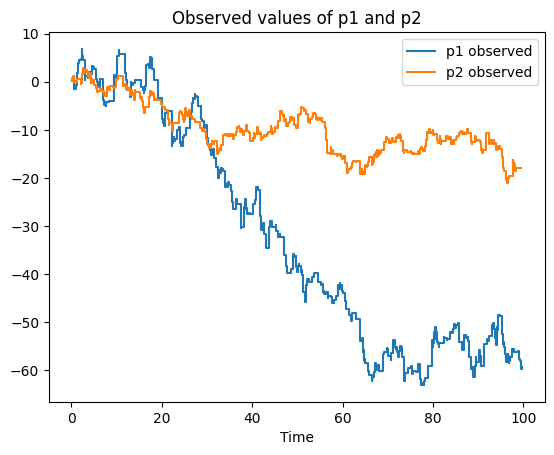

In [46]:
p1_obs, p2_obs = observe_p1_p2(p1,p2,T1,T2,times)
plt.step(T1,p1_obs,where='post',label='p1 observed')
plt.step(T2,p2_obs,where='post',label='p2 observed')
plt.title("Observed values of p1 and p2")
plt.legend()
plt.xlabel("Time")
plt.show()

Covariance computation :

In [47]:
true_covariance_value = rho*sigma1*sigma2*T
N_paths = 50
tau_values = [0.01,0.02,0.05,0.1,0.2,0.5,1,2,5,10]
results = {}
for tau in tau_values:
    results[tau] = []

for path in range(N_paths):
    times,p1,p2 = p1_p2(sigma1,sigma2,rho,T)
    T1,T2 = observation_times_p1_p2(mu1,mu2,T)
    for tau in tau_values:
        estimator = standard_covariance_estimator(T1,T2,p1,p2,times,tau)
        results[tau].append(estimator)

means = [np.mean(results[tau]) for tau in tau_values]
stds = [np.std(results[tau]) for tau in tau_values]

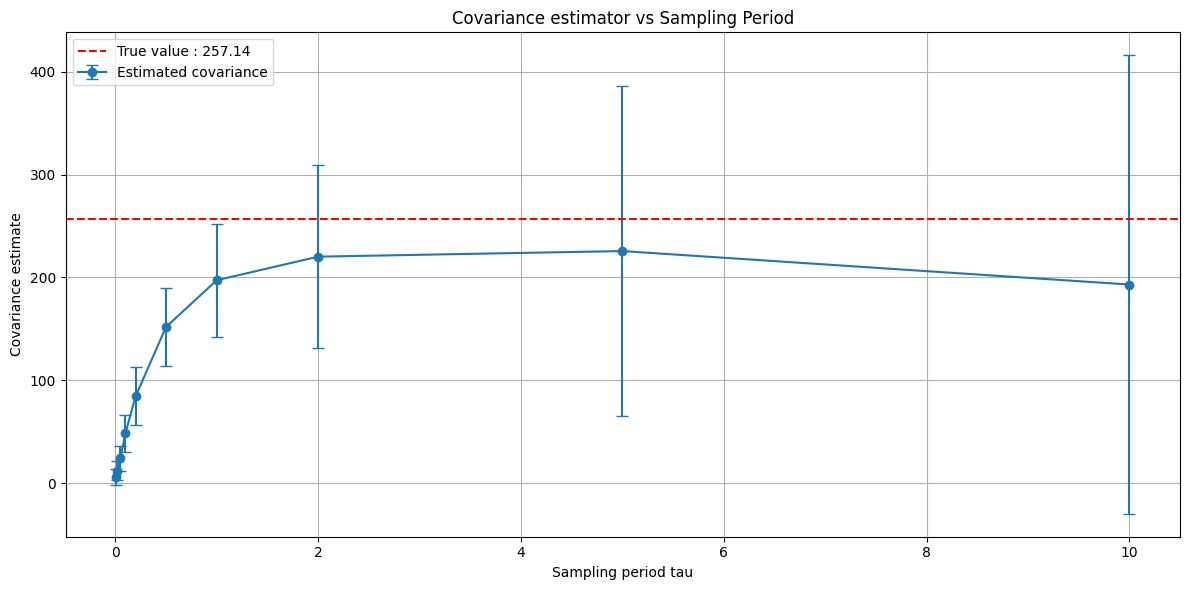

In [48]:
plt.figure(figsize=(12,6))
plt.errorbar(tau_values,means,yerr=stds,fmt='o-',capsize=4,label="Estimated covariance")
plt.axhline(true_covariance_value, color='r', linestyle='--', label=f"True value : {true_covariance_value:.2f}")
plt.xlabel("Sampling period tau")
plt.ylabel("Covariance estimate")
plt.title("Covariance estimator vs Sampling Period")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
print(f"True value of covariance : {true_covariance_value:.4f}")
for tau in tau_values :
    print(f"\ntau = {tau}")
    print(f"mean of estimated covariance = {np.mean(results[tau]):.4f}")
    print(f"standard deviation of estimated covariance = {np.std(results[tau]):.4f}")

True value of covariance : 257.1429

tau = 0.01
mean of estimated covariance = 5.8229
standard deviation of estimated covariance = 7.4712

tau = 0.02
mean of estimated covariance = 12.1632
standard deviation of estimated covariance = 9.4926

tau = 0.05
mean of estimated covariance = 23.9834
standard deviation of estimated covariance = 12.3077

tau = 0.1
mean of estimated covariance = 48.5416
standard deviation of estimated covariance = 18.1603

tau = 0.2
mean of estimated covariance = 84.3474
standard deviation of estimated covariance = 28.2501

tau = 0.5
mean of estimated covariance = 151.8080
standard deviation of estimated covariance = 38.3486

tau = 1
mean of estimated covariance = 197.2915
standard deviation of estimated covariance = 55.1260

tau = 2
mean of estimated covariance = 220.2129
standard deviation of estimated covariance = 88.7518

tau = 5
mean of estimated covariance = 225.6654
standard deviation of estimated covariance = 160.5130

tau = 10
mean of estimated covariance

Looking at the result, we have that :

For a small $\tau$ value, the estimator is close to 0 with a very low standard deviation, which means it is highly biased since it is not the expected value. This can be explained with the fact that since the two brown are rarely observed in the same time window, the brownian motions (or assets) appear uncorrelated : we expected this result as explained before, since no changes were captured by the random observation times on both assets during the same observation window because of the sampling period, we just sum terms that are equal to 0.

For a big $\tau$ value, the estimator converges to the expected value $\rho \sigma _1 \sigma _2 T$, but with a very high standard deviation.

Looking at the previous article mentioned (page 2 in introduction), this effect of having two correlated assets being seemingly uncorrelated from random discrete observations (for $\tau$ value being low) is called the **Epps effect** (https://en.wikipedia.org/wiki/Epps_effect), and it suggests that there is an optimal $\tau$ such that our estimator is close to the expected value while retaining a small variance.

In our case, even with $\tau = 5$ where it seems to yield the best results, the standard deviation is so high that estimation may fail to meet the expected value.

___

### 3. Empirical intensities and LOB features

#### 3.1 Empirical intensity of trades vs the rescaled observed queue size

We want to estimate the intensity function of trades (we did before by using the trade dataset), but this time by using LOB features, more precisely rescaled observed queue size (and for question 3.2 we will be using bid-ask spread).

We expect that a larger queue at the best quotes reduces the price impact during execution of market orders, which directly implies that more market orders will go through (since lower risks).

To proceed, we identify the LOB state just before a trade occurs : we then estimate the intensity using the identified LOB states over all the trades.

We can do this estimation with the following formula :


$\lambda (t) \approx \dfrac{\text{Mean number of events in }[t,t+\delta t]}{\delta t}$

Using this equation, we have, by merging (using bins) the LOB states given the queue size :

$\hat{\lambda} (bin) = \dfrac{\text{Number of trades occuring while in that state/bin}}{\text{Total time the LOB remains in that state/bin}}$

This kind of computation will verify the condition used in the first part of the lab, being that :

$\int _0 ^T \lambda(s)ds = \text{Total number of events considered}$


___

We use the same trick with np.searchsorted as before to get the last LOB state before trades occur.

The goal is to transfer the state of the LOB pver time to the trades dataset so that we can compute everything on the same dataset.

In [50]:
def lob_state_before_trades(df_updates,df_trades):
    upd = df_updates.dropna(subset=['bq','aq','bp','ap']).sort_values('ts').reset_index(drop=True)
    trd = df_trades.sort_values('ts').reset_index(drop=True)
    indices = np.searchsorted(upd['ts'].values, trd['ts'].values, side='right')-1
    mask = indices>=0
    trd = trd[mask].copy()
    indices = indices[mask]
    trd['bq'] = upd['bq'].values[indices]
    trd['aq'] = upd['aq'].values[indices]
    trd['bp'] = upd['bp'].values[indices]
    trd['ap'] = upd['ap'].values[indices]
    return trd

Rescaling the queue sizes is required as raw queue sizes may differ across the 3 stocks considered (a stock may be more liquid than another).

By dividing the queue size with the daily mean queue, the rescaled queue sizes become comparable between the stocks :

$q = \dfrac{Q}{\bar{Q}}, \qquad Q = \dfrac{bq+aq}{2}$

We will also use the data from the 5 days to have more trades / LOB states and get a more precise intensity function estimate.

In [51]:
def compute_intensity_queue(stock_idx, n_bins,quantile_percent=100):
    all_q_trades = []
    all_q_lob    = []
    all_dur_lob  = []
    for day_idx in range(len(day_ids)):
        df_upd = updates[stock_idx, day_idx].copy()
        df_trd = trades[stock_idx, day_idx].copy()

        upd = df_upd.dropna(subset=['bq','aq','bp','ap']).sort_values('ts').reset_index(drop=True)
        mid_q = (upd['bq']+upd['aq'])/2 #Q
        mean_q = mid_q.mean() #Q bar
        rescaled_q_lob = (mid_q/mean_q).values
        
        durations = upd['ts'].diff().shift(-1).dt.total_seconds().fillna(0).values
        all_q_lob.append(rescaled_q_lob)
        all_dur_lob.append(durations)
        trd_lob = lob_state_before_trades(df_upd, df_trd)
        mid_q_trade = (trd_lob['bq']+trd_lob['aq'])/2
        all_q_trades.append((mid_q_trade / mean_q).values)

    all_q_trades = np.concatenate(all_q_trades)
    all_q_lob    = np.concatenate(all_q_lob)
    all_dur_lob  = np.concatenate(all_dur_lob)
    bin_edges = np.percentile(all_q_lob, np.linspace(0, quantile_percent, n_bins + 1)) #From quantiles of the pooled LOB
    bin_edges = np.unique(bin_edges) #To prevent errors
    bin_centers = (bin_edges[:-1] + bin_edges[1:])/2

    trade_counts, _ = np.histogram(all_q_trades, bins=bin_edges)
    time_in_bin = np.array([all_dur_lob[(all_q_lob >= bin_edges[i]) & (all_q_lob < bin_edges[i+1])].sum() for i in range(len(bin_edges)-1)])
    intensity = np.where(time_in_bin > 0, trade_counts / time_in_bin, 0.0) #Empirical intensity
    return bin_centers, intensity


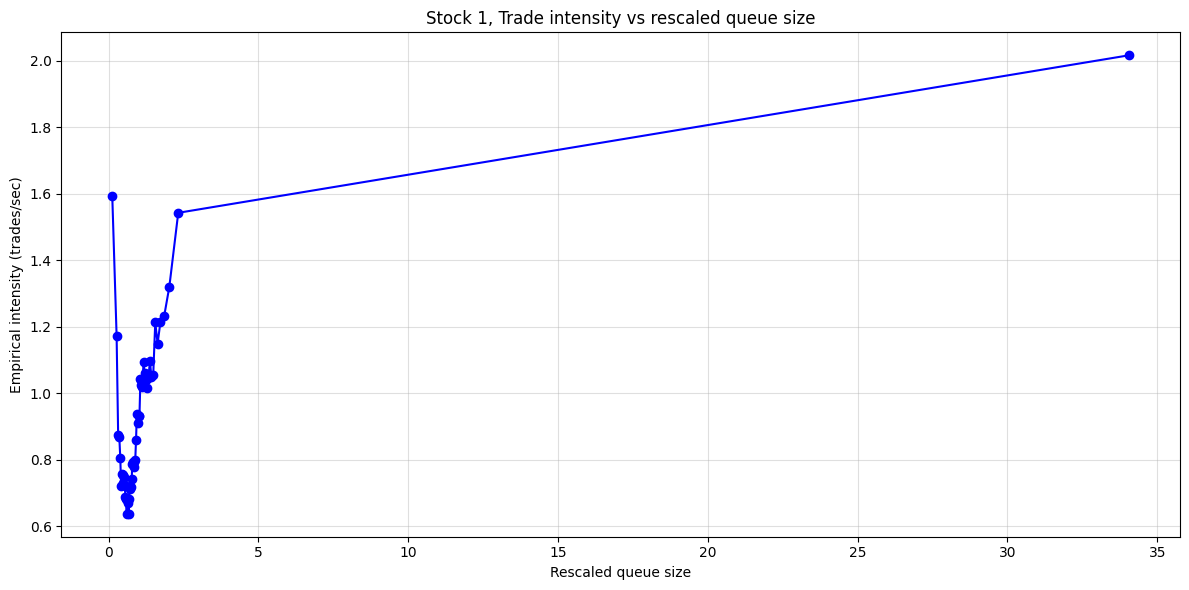

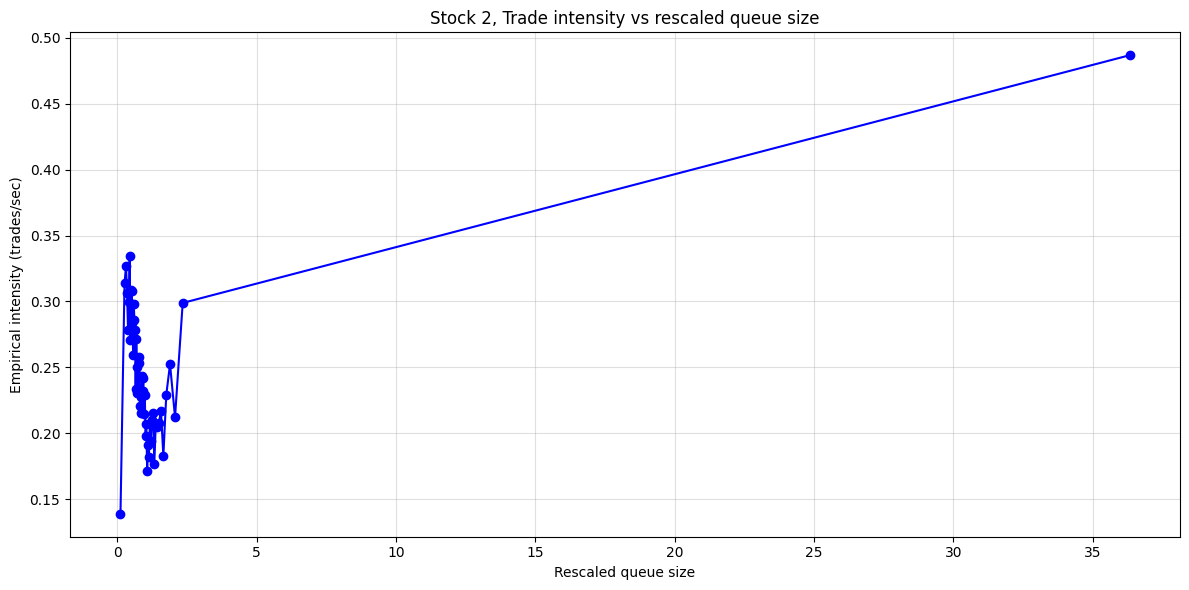

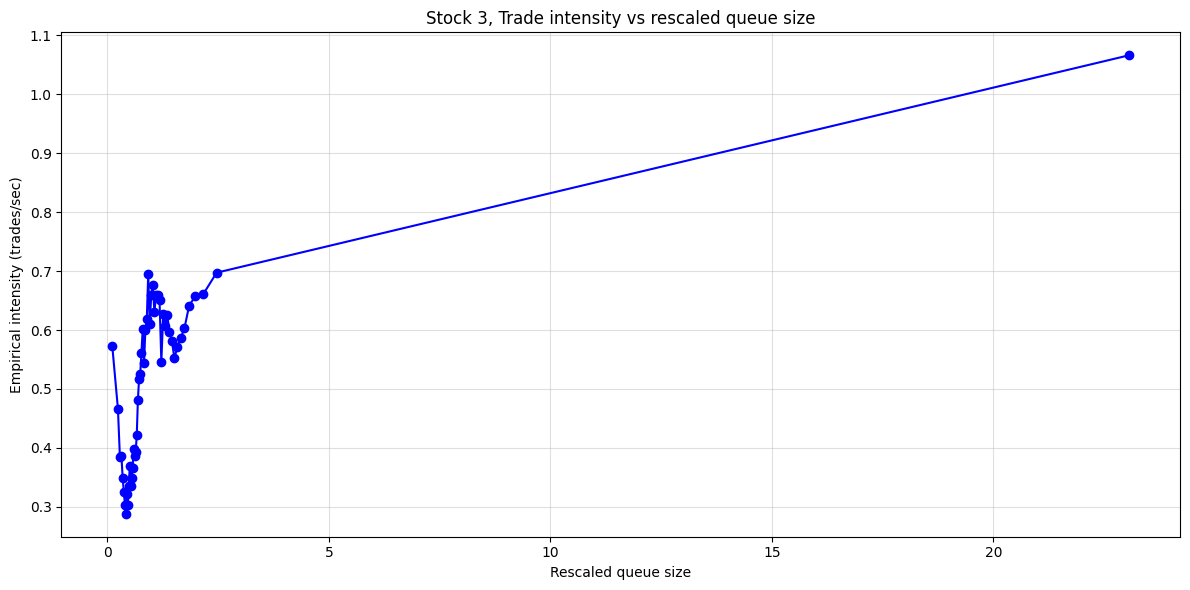

In [52]:
n_bins = 50
for stock_idx in range(3):
    bin_centers, intensity = compute_intensity_queue(stock_idx,n_bins,100)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(bin_centers, intensity, 'o-', color='b')
    ax.set_xlabel("Rescaled queue size")
    ax.set_ylabel("Empirical intensity (trades/sec)")
    ax.set_title(f"Stock {stock_idx+1}, Trade intensity vs rescaled queue size")
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()


To remove the extreme points for all the stock, we remove the top 1% quantile of our data.

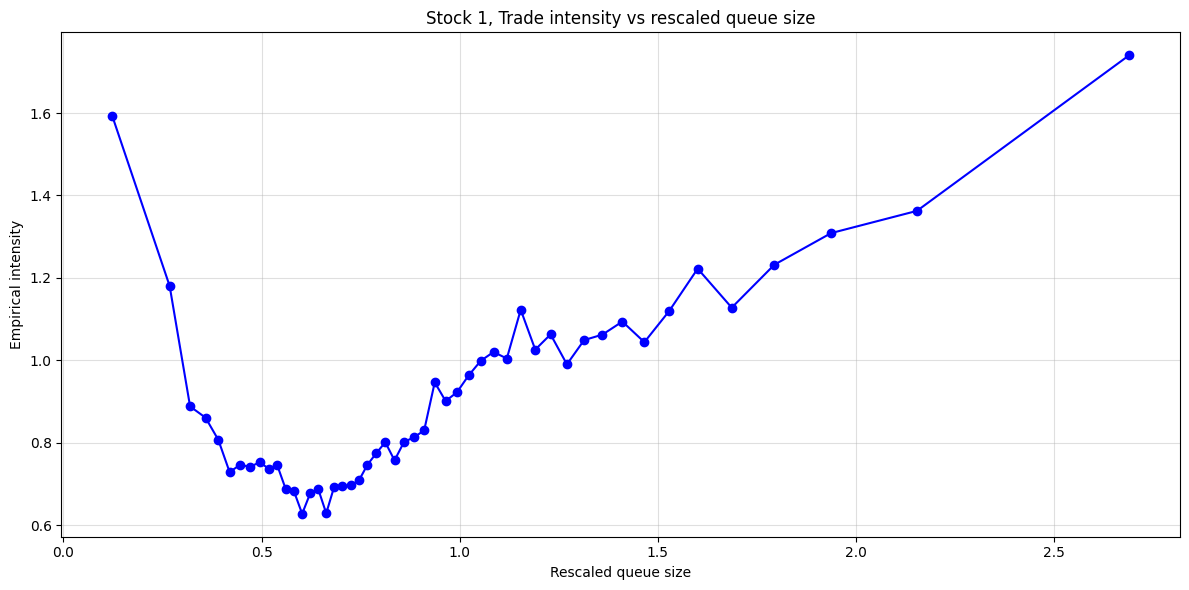

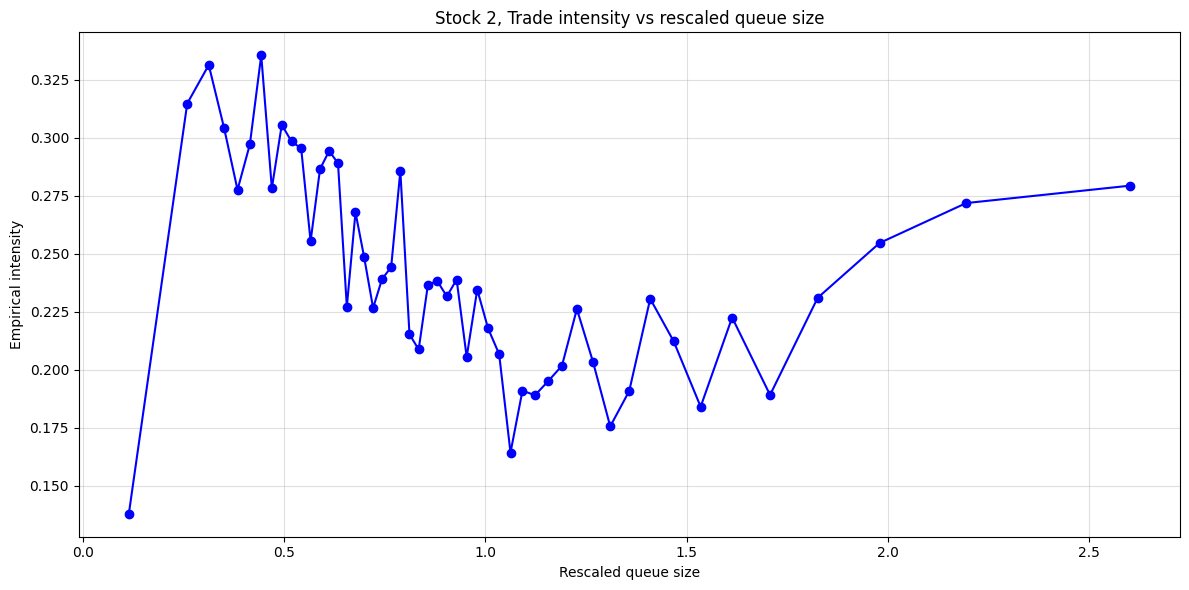

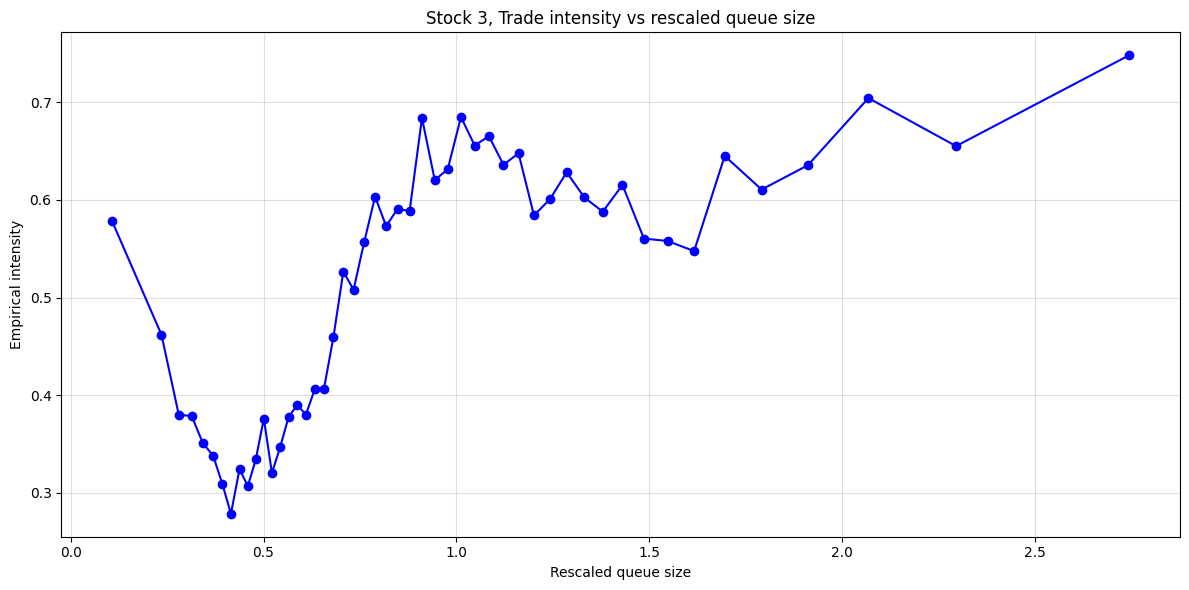

In [53]:
for stock_idx in range(3):
    bin_centers, intensity = compute_intensity_queue(stock_idx,n_bins,99)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(bin_centers, intensity, 'o-', color='b')
    ax.set_xlabel("Rescaled queue size")
    ax.set_ylabel("Empirical intensity")
    ax.set_title(f"Stock {stock_idx+1}, Trade intensity vs rescaled queue size")
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()


From the graphs we obtained, we can conclude that as shown in part 1 of our lab, the intensity of our trades depends on many parameters and is not constant : we showed that the intensity function was U-shaped vs trade times, and now we can do some observations of our intensity behaviour with respect to rescaled queue size.

First, we will make our analysis with graphs of stock 1 and 3, as they seem to be easier to analyze. 

- **For small values of rescaled queue size** ($<1$), we have that the intensity is rather low (we will tackle very low queue size afterwards because they do not fit in this category), because as expected a smaller queue size at the best quotes increases the price impact during execution of market orders, which means higher risks of price change during execution.
- **For high values of rescaled queue size** ($>1$), we have that the intensity of trades is increasing (seemingly linearly) with queue size because as expected a higher queue size at the best quotes reduces the price impact during execution of market orders, which means lower risks of price change during execution, which attracts market players to place market orders.
- Finally, **for very small rescaled queue sizes** ($<0.5$), we can consider that it is a direct impact of the previous point : since the high queue sizes attract market players to execute, it drastically reduces the queue sizes at once, and since many large trades of such kind will occur at the same time (since they want to use this opportunity with large queue sizes), the very low queue sizes are being artificially inflated in intensity as a result of the queue size being consumed. We came up with this conclusion as we had no other economic interpretation of this phenomenon.

Looking back at it, stock 2 behaves more erratically but keeps the same trend : high intensity with low queue sizes, decreases progressively with queue size, and then increases again with queue size.

___

#### 3.2 Empirical intensity of trades vs observed spreads

The bid-ask spread is : $S = \text{ask}_{\text{price}} - \text{bid}_{\text{price}} = ap - bp$

As we did previously with the queue sizes for our 3 stocks, we can rescale the spread by its daily mean :

$s = \dfrac{S}{\bar{S}}$

As we did previously, we will again use the data of our 5 days, and take the LOB state right before a trade occur to know the spread. We will then merge by state using bins as we did for 3.1, and estimate our intensity based on the spreads.

We expect that a high spread will reduce trade intensity, because market orders will be costly to reverse, and that on the contrary low spreads will lead to high trade intensity, as it will be a sign of a liquid market, which implies lots of market orders as well. Low spread also means that market players who want to execute their orders can do it without losing too much money on either side of the market, which incites market players to do it while the spread is still low, thus increasing the intensity.

In [54]:
def compute_intensity_vs_spread(stock_idx, n_bins, quantile_percent = 100):
    all_s_trades = []   # rescaled spread at each trade
    all_s_lob    = []   # rescaled spread at each LOB snapshot
    all_dur_lob  = []   # duration of each LOB snapshot (seconds)

    for day_idx in range(len(day_ids)):
        df_upd = updates[stock_idx, day_idx].copy()
        df_trd = trades[stock_idx, day_idx].copy()
        upd = df_upd.dropna(subset=['bp', 'ap']).sort_values('ts').reset_index(drop=True)
        spread = (upd['ap'] - upd['bp']).clip(lower=0)
        mean_spread = spread[spread > 0].mean()
        rescaled_s_lob = (spread / mean_spread).values
        durations = upd['ts'].diff().shift(-1).dt.total_seconds().fillna(0).values
        mask_pos = rescaled_s_lob > 0
        all_s_lob.append(rescaled_s_lob[mask_pos])
        all_dur_lob.append(durations[mask_pos])
        trd_lob = lob_state_before_trades(df_upd, df_trd)
        trd_lob = trd_lob.dropna(subset=['bp', 'ap'])
        spread_trade = (trd_lob['ap'] - trd_lob['bp']).clip(lower=0)
        rescaled_s_trade = spread_trade / mean_spread
        all_s_trades.append(rescaled_s_trade[rescaled_s_trade > 0].values)

    all_s_trades = np.concatenate(all_s_trades)
    all_s_lob    = np.concatenate(all_s_lob)
    all_dur_lob  = np.concatenate(all_dur_lob)

    bin_edges = np.percentile(all_s_lob, np.linspace(0, quantile_percent, n_bins + 1)) #From quantiles of the pooled LOB
    bin_edges = np.unique(bin_edges) #To prevent errors
    bin_centers = (bin_edges[:-1] + bin_edges[1:])/2
    trade_counts, _ = np.histogram(all_s_trades,bins=bin_edges)
    time_in_bin = np.array([all_dur_lob[(all_s_lob >= bin_edges[i]) & (all_s_lob < bin_edges[i+1])].sum()for i in range(len(bin_edges)-1)])
    intensity = np.where(time_in_bin > 0, trade_counts / time_in_bin, 0.0)
    return bin_centers, intensity

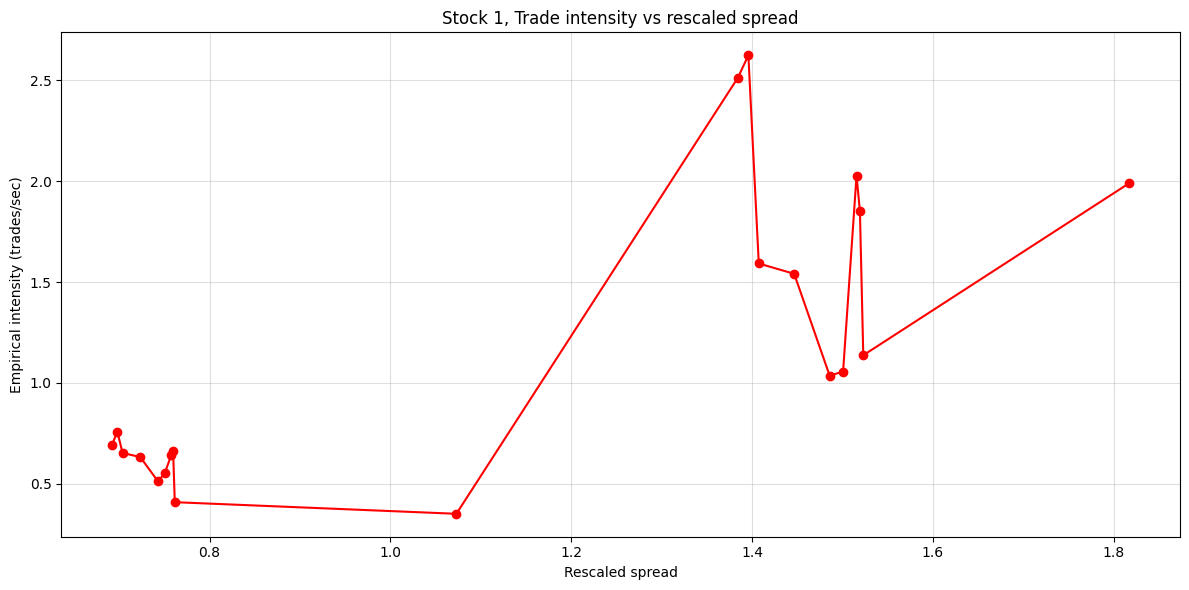

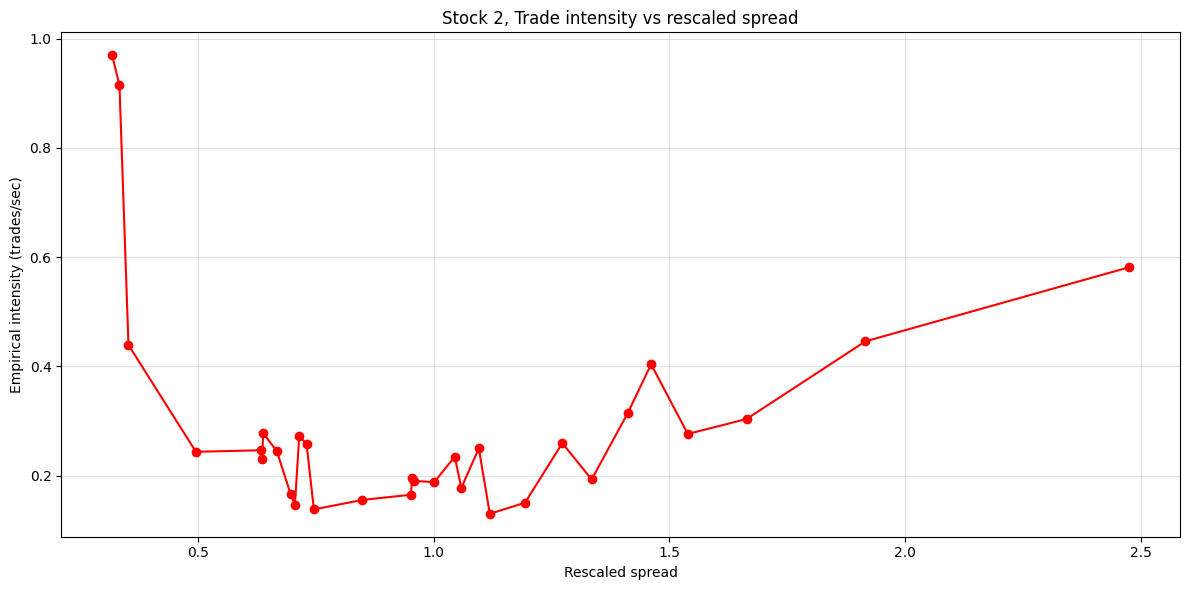

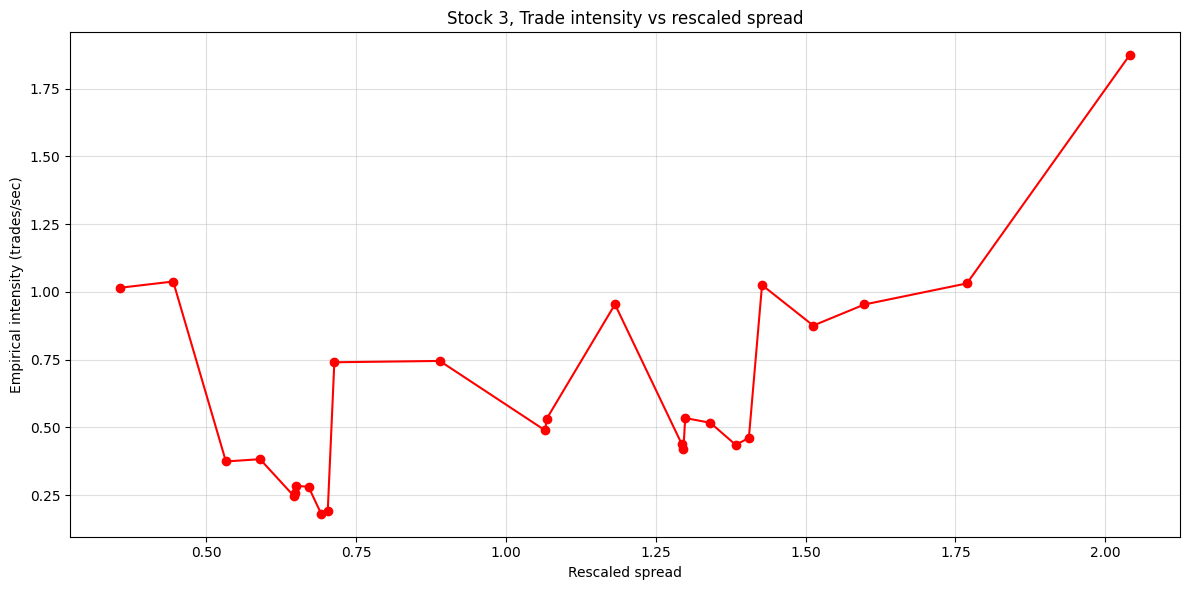

In [55]:
n_bins = 50

for stock_idx in range(3):
    bin_centers, intensity = compute_intensity_vs_spread(stock_idx, n_bins, 99)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(bin_centers, intensity, 'o-', color='r')
    ax.set_xlabel("Rescaled spread")
    ax.set_ylabel("Empirical intensity (trades/sec)")
    ax.set_title(f"Stock {stock_idx+1}, Trade intensity vs rescaled spread")
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

From those graphs (obtained removing the 1% extreme data points already), we don't observe the expected result at all.

Only stock 2 seems to behave as expected with low spread and mid spread, however they all have in common the fact that high spreads results in high trade intensity, which we find faulty.

___